In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc, classification_report
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
import matplotlib.gridspec as gridspec

In [24]:
!pip install polars

import polars as pl

In [31]:
def plot_histogram(df, column, bins=50, title=None, xlabel=None, ylabel="Frequency", yscale ='linear'):
    if column not in df.columns:
        raise ValueError(f"Column '{column}' not found in DataFrame.")

    plt.figure()
    plt.hist(df[column], bins=bins, edgecolor='black')
    plt.title(title or f"Histogram of {column}")
    plt.xlabel(xlabel or column)
    plt.ylabel(ylabel)
    plt.yscale(yscale)
    plt.grid(True)
    plt.show()

def delta_phi(phi1, phi2):
    """Computes the difference in phi, handling the wrap-around at pi."""
    # Ensure inputs are numpy arrays for broadcasting
    dphi = np.asarray(phi1) - np.asarray(phi2)
    dphi = np.where(dphi > np.pi, dphi - 2 * np.pi, dphi)
    dphi = np.where(dphi < -np.pi, dphi + 2 * np.pi, dphi)
    return dphi

def delta_r(eta1, eta2, phi1, phi2):
    """Computes the delta R distance between two objects."""
    deta = np.asarray(eta1) - np.asarray(eta2)
    dphi = delta_phi(phi1, phi2)
    return np.sqrt(deta**2 + dphi**2)




In [4]:
def print_nan_counts(df):
    """
    Counts and prints the number of NaN values in each column of a DataFrame.
    Only columns with at least one NaN are displayed.
    """
    # Count the number of NaNs in each column
    nan_counts = df.isna().sum()
    
    # Filter the series to only include columns where the count is greater than 0
    missing_data = nan_counts[nan_counts > 0]
    
    # Check if the filtered series is empty
    if missing_data.empty:
        print("No NaN values found in any column.")
    else:
        print("NaN counts per column:")
        print("-" * 20)
        print(missing_data)
        
    # Optional: return the filtered series in case you need it for further analysis
    return missing_data

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

def plot_2d_histogram(df: pd.DataFrame, x_col: str, y_col: str, 
                      bins=50, weighted: bool = False, 
                      log_z: bool = False, cmap: str = 'viridis',
                      title: str = None):
    """
    Plots a 2D histogram for two specified columns in a DataFrame.
    Includes optional weighting, log-scaled color mapping, and dynamic axes zooming.
    """
    # 1. Validation
    if x_col not in df.columns or y_col not in df.columns:
        raise ValueError(f"Columns '{x_col}' and/or '{y_col}' not found in DataFrame.")
    if weighted and 'weight' not in df.columns:
        raise ValueError("Weighted is True but 'weight' column not found in DataFrame.")

    # 2. Data Cleaning
    cols_to_keep = [x_col, y_col]
    if weighted:
        cols_to_keep.append('weight')
        
    plot_df = df[cols_to_keep].dropna()

    if len(plot_df) == 0:
        raise ValueError("No valid data left after removing NaNs.")

    # Cast to float64 to avoid NumPy float32 bugs during binning operations
    x_data = plot_df[x_col].values.astype(np.float64)
    y_data = plot_df[y_col].values.astype(np.float64)
    weights = plot_df['weight'].values if weighted else None

    # 3. Dynamic Axes Boundaries (Zooming past 1% outliers)
    x_lower, x_upper = np.percentile(x_data, [1, 99])
    y_lower, y_upper = np.percentile(y_data, [1, 99])
    
    # If bins is an integer, apply it to both axes within the 1-99 percentile bounds
    if isinstance(bins, int):
        x_bins = np.linspace(x_lower, x_upper, bins + 1)
        y_bins = np.linspace(y_lower, y_upper, bins + 1)
        bins = [x_bins, y_bins]

    # 4. Plotting
    plt.figure(figsize=(9, 7))
    
    # Handle log scale for the color dimension (Z-axis)
    norm = LogNorm() if log_z else None

    # matplotlib's hist2d handles weights natively
    counts, xedges, yedges, im = plt.hist2d(
        x=x_data, 
        y=y_data, 
        bins=bins, 
        weights=weights, 
        cmap=cmap, 
        norm=norm,
        cmin=1e-9 if log_z else None # Hides completely empty bins if log scaled
    )

    # 5. Aesthetics
    cbar = plt.colorbar(im)
    cbar_label = "Weighted Frequency" if weighted else "Frequency"
    if log_z:
        cbar_label += " (Log Scale)"
    cbar.set_label(cbar_label)

    plt.xlabel(x_col)
    plt.ylabel(y_col)
    
    plot_title = title or f"2D Histogram of {y_col} vs {x_col}"
    if weighted:
        plot_title += " (Weighted)"
    plt.title(plot_title)
    
    # Apply limits to zoom in on the dense regions
    plt.xlim(x_lower, x_upper)
    plt.ylim(y_lower, y_upper)
    
    plt.tight_layout()
    plt.show()

In [6]:
def compute_system_pt(fj_pt, fj_phi, muon_pt, muon_phi, met_pt, met_phi):
    """
    Computes the transverse momentum (Pt) of the vector sum of a fatjet, 
    a muon, and MET. Mass and Eta are omitted as they do not affect Pt sums.
    """
    # 1. Convert Pt and Phi to Cartesian Px and Py
    fj_px = fj_pt * np.cos(fj_phi)
    fj_py = fj_pt * np.sin(fj_phi)
    
    muon_px = muon_pt * np.cos(muon_phi)
    muon_py = muon_pt * np.sin(muon_phi)
    
    # met_px = met_pt * np.cos(met_phi)
    # met_py = met_pt * np.sin(met_phi)
    
    # 2. Sum the components in the transverse plane
    sum_px = fj_px + muon_px # + met_px
    sum_py = fj_py + muon_py # + met_py
    
    # 3. Calculate resulting Pt
    result_pt = np.sqrt(sum_px**2 + sum_py**2)
    
    return result_pt

In [39]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import roc_curve, auc

def plot_model_comparison(df, score_cols, label_col='label', weight_col='weight', baseline_idx=0):
    """
    Plots overlaid ROC curves and Efficiency vs Rejection curves for a list of models,
    along with their differences/ratios relative to a baseline model in bottom panels.
    
    Args:
        df: Pandas DataFrame containing the data.
        score_cols: List of strings for the score columns (e.g., ['score_m1', 'score_m2', 'score_m3']).
        label_col: String for the target label column.
        weight_col: String for the weights column.
        baseline_idx: Index of the model in `score_cols` to use as the baseline for diff/ratio plots.
    """
    if not isinstance(score_cols, list) or len(score_cols) < 2:
        raise ValueError("score_cols must be a list containing at least two column names.")
        
    print(f"Comparing models: {', '.join(score_cols)}...")
    baseline_col = score_cols[baseline_idx]
    
    y_true = df[label_col].values
    weights = df[weight_col].values if weight_col in df.columns else None

    # Calculate and store metrics for all models
    metrics = {}
    for col in score_cols:
        y_score = df[col].values
        fpr, tpr, _ = roc_curve(y_true, y_score, sample_weight=weights)
        auc_val = auc(fpr, tpr)
        
        with np.errstate(divide='ignore'):
            rej = np.where(fpr > 0, 1.0 / fpr, np.nan)
            
        metrics[col] = {'fpr': fpr, 'tpr': tpr, 'auc': auc_val, 'rej': rej}

    # Setup the figure with GridSpec (Top panel 3x larger than bottom panel)
    fig = plt.figure(figsize=(16, 8))
    gs = gridspec.GridSpec(2, 2, height_ratios=[3, 1], hspace=0.1)

    # Main Axes
    ax_roc_main = fig.add_subplot(gs[0, 0])
    ax_roc_diff = fig.add_subplot(gs[1, 0], sharex=ax_roc_main)
    ax_rej_main = fig.add_subplot(gs[0, 1])
    ax_rej_diff = fig.add_subplot(gs[1, 1], sharex=ax_rej_main)

    # Grids for interpolation (used for difference/ratio panels)
    fpr_grid = np.linspace(0.001, 1.0, 1000)
    tpr_grid = np.linspace(0.1, 0.99, 1000)
    
    # Baseline interpolations
    baseline_tpr_interp = np.interp(fpr_grid, metrics[baseline_col]['fpr'], metrics[baseline_col]['tpr'])
    baseline_rej_interp = np.interp(tpr_grid, metrics[baseline_col]['tpr'], metrics[baseline_col]['rej'])

    # Standard color palette
    colors = plt.cm.tab10.colors

    # Loop through all models and plot
    for i, col in enumerate(score_cols):
        color = colors[i % len(colors)]
        m = metrics[col]
        
        # --- Main ROC ---
        ax_roc_main.plot(m['fpr'], m['tpr'], lw=2, label=f"{col} (AUC = {m['auc']:.4f})", color=color)
        
        # --- Main Eff vs Rej ---
        ax_rej_main.plot(m['tpr'], m['rej'], lw=2, label=f"{col}", color=color)

        # --- Diff & Ratio (Skip baseline against itself) ---
        if col != baseline_col:
            # ROC Difference (Current - Baseline)
            tpr_interp = np.interp(fpr_grid, m['fpr'], m['tpr'])
            roc_diff = tpr_interp - baseline_tpr_interp 
            ax_roc_diff.plot(fpr_grid, roc_diff, color=color, lw=1.5)
            
            # Rejection Ratio (Current / Baseline)
            rej_interp = np.interp(tpr_grid, m['tpr'], m['rej'])
            with np.errstate(divide='ignore', invalid='ignore'):
                rej_ratio = np.divide(rej_interp, baseline_rej_interp)
                rej_ratio = np.nan_to_num(rej_ratio, nan=1.0, posinf=1.0, neginf=1.0)
            ax_rej_diff.plot(tpr_grid, rej_ratio, color=color, lw=1.5)

    # ==========================================
    # Formatting Panel Column 1: ROC Curves
    # ==========================================
    ax_roc_main.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
    ax_roc_main.set_ylabel('Signal Efficiency (TPR)')
    ax_roc_main.set_title('ROC Curve Comparison')
    ax_roc_main.legend(loc='lower right')
    ax_roc_main.grid(True, linestyle=':', alpha=0.6)
    plt.setp(ax_roc_main.get_xticklabels(), visible=False)

    ax_roc_diff.axhline(0, color='black', linestyle='--', lw=1)
    ax_roc_diff.set_xlabel('False Positive Rate (FPR)')
    ax_roc_diff.set_ylabel(fr'$\Delta$ TPR\n(vs {baseline_col})', fontsize=10)
    ax_roc_diff.grid(True, linestyle=':', alpha=0.6)

    # ==========================================
    # Formatting Panel Column 2: Eff vs Rejection
    # ==========================================
    ax_rej_main.set_yscale('log')
    ax_rej_main.set_ylabel('Background Rejection (1 / FPR)')
    ax_rej_main.set_title('Efficiency vs. Background Rejection')
    ax_rej_main.legend(loc='upper right')
    ax_rej_main.grid(True, which="both", linestyle=':', alpha=0.6)
    plt.setp(ax_rej_main.get_xticklabels(), visible=False)


    if np.max(rej_ratio) > 10:
        ax_rej_diff.set_yscale('log')

    ax_rej_diff.axhline(1, color='black', linestyle='--', lw=1)
    ax_rej_diff.set_xlabel('Signal Efficiency (TPR)')
    ax_rej_diff.set_ylabel(f'Ratio\n(vs {baseline_col})', fontsize=10)
    ax_rej_diff.grid(True, linestyle=':', alpha=0.6)

    plt.tight_layout()
    plt.show()

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_histogram_by_type(df, value_column, type_column="type", bins=50, alpha=0.7, 
                           filename='default_file', title=None, log_y=False, weighted=False):
    if value_column not in df.columns or type_column not in df.columns:
        raise ValueError(f"Columns '{value_column}' and/or '{type_column}' not found in DataFrame.")
    if weighted and 'weight' not in df.columns:
        raise ValueError("Weighted is True but 'weight' column not found in DataFrame.")

    # Create a working copy of the specific columns and drop NAs to avoid alignment issues
    cols_to_keep = [value_column, type_column]
    if weighted:
        cols_to_keep.append('weight')
        
    plot_df = df[cols_to_keep].dropna().copy()
    
    # Check if we should treat the type_column as continuous
    if plot_df[type_column].nunique() > 15 and pd.api.types.is_numeric_dtype(plot_df[type_column]):
        # pd.cut automatically finds min/max and splits into equal-width categories
        plot_df['plot_category'] = pd.cut(plot_df[type_column], bins=5)
    else:
        # Otherwise, use the original distinct types
        plot_df['plot_category'] = plot_df[type_column]

    data = plot_df[value_column]
    
    # Discard low-frequency tail zones to stretch the x-axis 
    # and reveal more detail in the highly populated bins
    lower_bound = np.percentile(data, 1)
    upper_bound = np.percentile(data, 99)
    bin_edges = np.linspace(lower_bound, upper_bound, bins + 1)

    plt.figure(figsize=(8, 6))

    # Collect the data for each type into lists
    subsets = []
    weights_list = [] if weighted else None
    labels = []
    
    # Use sort_index() on value_counts to get the unique categories in logical/numerical order
    unique_categories = plot_df['plot_category'].value_counts().sort_index().index

    for t in unique_categories:
        subset_df = plot_df[plot_df['plot_category'] == t]
        subset = subset_df[value_column]
        
        # Skip empty bins (which can sometimes be generated by pd.cut)
        if len(subset) == 0:
            continue
            
        subsets.append(subset)
        if weighted:
            weights_list.append(subset_df['weight'])
        
        # Update the label to include the event count (or sum of weights)
        if weighted:
            count = subset_df['weight'].sum()
            labels.append(f"{t} (w={count:.1f})")
        else:
            count = len(subset)
            labels.append(f"{t} (n={count})")

    # Plot all subsets at once with stacked=True
    plt.hist(subsets, bins=bin_edges, alpha=alpha, label=labels, stacked=True, 
             edgecolor='black', histtype='bar', log=log_y, weights=weights_list)

    plt.xlabel(value_column)
    plt.ylabel("Weighted Frequency" if weighted else "Frequency")
    
    title = title or f"Histogram of {value_column} by {type_column} from {filename}"
    plt.title(title)
    plt.legend(title=type_column)
    plt.grid(True)
    plt.tight_layout()
    plt.show()


def plot_histogram_diffs(df1: pd.DataFrame, df2: pd.DataFrame, columns: list, 
                         log_scale: bool = False, n_bins: int = 50, 
                         df1_label: str = 'DataFrame 1', df2_label: str = 'DataFrame 2',
                         min_freq: float = 0, max_x_cap: float = 1000.0, weighted: bool = False):
    """
    Plots overlaid normalized histograms for selected columns from two DataFrames.
    Filters out exact zeros, discards values above max_x_cap, removes bins below min_freq, 
    and zooms the x-axis to fit the remaining valid data.
    """
    if weighted and ('weight' not in df1.columns or 'weight' not in df2.columns):
        raise ValueError("Weighted is True but 'weight' column is missing in one or both DataFrames.")

    for col in columns:
        if col not in df1.columns or col not in df2.columns:
            print(f"Warning: Column '{col}' not found in both DataFrames. Skipping.")
            continue

        # 1. Clean data: Drop NaNs, exact zeros, and apply the max_x_cap
        cols_to_keep = [col, 'weight'] if weighted else [col]
        
        df1_clean = df1[cols_to_keep].dropna()
        df1_clean = df1_clean[(df1_clean[col] != 0.0) & (df1_clean[col] <= max_x_cap)]
        data1 = df1_clean[col]
        weights1 = df1_clean['weight'] if weighted else None
        
        df2_clean = df2[cols_to_keep].dropna()
        df2_clean = df2_clean[(df2_clean[col] != 0.0) & (df2_clean[col] <= max_x_cap)]
        data2 = df2_clean[col]
        weights2 = df2_clean['weight'] if weighted else None

        if len(data1) == 0 or len(data2) == 0:
            print(f"Warning: Column '{col}' has no valid data after filtering. Skipping.")
            continue

        # Discard low-frequency tail zones to stretch the x-axis 
        lower_bound1 = np.percentile(data1, 1)
        lower_bound2 = np.percentile(data2, 1)

        upper_bound1 = np.percentile(data1, 99)
        upper_bound2 = np.percentile(data2, 99)

        min_val = min(lower_bound1, lower_bound2)
        max_val = max(upper_bound1, upper_bound2)
        bins = np.linspace(min_val, max_val, n_bins + 1)
        bin_centers = 0.5 * (bins[:-1] + bins[1:])
        width = bins[1] - bins[0]

        # 3. Calculate raw (or weighted) counts using numpy
        counts1, _ = np.histogram(data1, bins=bins, weights=weights1)
        counts2, _ = np.histogram(data2, bins=bins, weights=weights2)

        # 4. Filter and Rescale to Density
        # --- For DataFrame 1 ---
        freq1 = counts1 / counts1.sum()
        filtered_freq1 = np.where(freq1 >= min_freq, freq1, 0)
        
        if filtered_freq1.sum() > 0:
            density1 = (filtered_freq1 / filtered_freq1.sum()) / width
        else:
            density1 = np.zeros_like(filtered_freq1)

        # --- For DataFrame 2 ---
        freq2 = counts2 / counts2.sum()
        filtered_freq2 = np.where(freq2 >= min_freq, freq2, 0)
        
        if filtered_freq2.sum() > 0:
            density2 = (filtered_freq2 / filtered_freq2.sum()) / width
        else:
            density2 = np.zeros_like(filtered_freq2)

        # 5. Determine the new x-axis bounds based on surviving bins
        valid_bins_mask = (density1 > 0) | (density2 > 0)
        
        if not valid_bins_mask.any():
            print(f"Warning: No bins survived the {min_freq} threshold for column '{col}'. Skipping.")
            continue
            
        valid_indices = np.where(valid_bins_mask)[0]
        first_valid_idx = valid_indices[0]
        last_valid_idx = valid_indices[-1]
        
        x_min_zoom = bins[first_valid_idx]
        x_max_zoom = bins[last_valid_idx + 1]

        # 6. Calculate the difference (DF1 - DF2)
        hist_diff = density1 - density2

        # 7. Set up the figure and subplots
        fig, (ax1, ax2) = plt.subplots(
            nrows=2, ncols=1, figsize=(10, 8), 
            sharex=True, gridspec_kw={'height_ratios': [2, 1]}
        )

        # --- Top Subplot: Overlaid Histograms ---
        ax1.bar(bin_centers, density1, width=width, alpha=0.5, label=df1_label, color='blue', edgecolor='white', linewidth=0.5)
        ax1.bar(bin_centers, density2, width=width, alpha=0.5, label=df2_label, color='orange', edgecolor='white', linewidth=0.5)
        
        if log_scale:
            ax1.set_yscale('log')
            valid_densities = np.concatenate([density1[density1 > 0], density2[density2 > 0]])
            if len(valid_densities) > 0:
                ax1.set_ylim(bottom=valid_densities.min() * 0.5)
                
        # Apply the zoomed x-axis limits here
        ax1.set_xlim(x_min_zoom, x_max_zoom)
            
        ax1.set_ylabel('Normalized Density')
        ax1.set_title(f'Distribution Comparison: {col} (Zeros removed, Weighted={weighted})')
        ax1.legend()
        ax1.grid(True, alpha=0.3)

        # --- Bottom Subplot: Difference ---
        diff_colors = ['blue' if val > 0 else 'orange' for val in hist_diff]
        ax2.bar(bin_centers, hist_diff, width=width, color=diff_colors, alpha=0.7)
        ax2.axhline(0, color='black', linestyle='--', linewidth=1)
        
        ax2.set_ylabel(f'Difference\n({df1_label} - {df2_label})')
        ax2.set_xlabel(col)
        ax2.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()


def _weighted_quantile(values, quantiles, sample_weight=None):
    """Helper function to calculate weighted quantiles."""
    values = np.array(values)
    quantiles = np.array(quantiles)
    if sample_weight is None:
        sample_weight = np.ones(len(values))
    sample_weight = np.array(sample_weight)

    # Sort values and weights
    sorter = np.argsort(values)
    values = values[sorter]
    sample_weight = sample_weight[sorter]

    # Calculate cumulative weights
    weighted_quantiles = np.cumsum(sample_weight) - 0.5 * sample_weight
    weighted_quantiles /= np.sum(sample_weight)

    return np.interp(quantiles, weighted_quantiles, values)


def plot_efficiency_vs_feature(df_sig, df_bkg, score_col, feature_col, fpr_thresholds=[0.001, 0.005], bins=25, weighted=False):
    """
    Calculates score thresholds based on target background False Positive Rates (FPR), 
    and plots the signal efficiency as a function of a specific physical feature, 
    including statistical error bars.
    """
    if weighted and ('weight' not in df_sig.columns or 'weight' not in df_bkg.columns):
        raise ValueError("Weighted is True but 'weight' column is missing in one or both DataFrames.")

    print(f"Evaluating Signal Efficiency vs {feature_col} using '{score_col}' (Weighted={weighted})...")

    # Clean the data to prevent NaN cascade and overflow errors
    bkg_cols = [score_col, 'weight'] if weighted else [score_col]
    df_bkg_clean = df_bkg[bkg_cols].dropna()
    
    sig_cols = [score_col, feature_col, 'weight'] if weighted else [score_col, feature_col]
    df_sig_clean = df_sig[sig_cols].dropna()

    if len(df_bkg_clean) == 0:
        raise ValueError(f"No valid background data left after removing NaNs.")
    if len(df_sig_clean) == 0:
        raise ValueError(f"No valid signal data left after removing NaNs.")

    # 1. Calculate Thresholds strictly from Background
    bg_scores = df_bkg_clean[score_col].values.astype(np.float64)
    bg_weights = df_bkg_clean['weight'].values if weighted else None
    
    thresholds = {}
    for fpr in fpr_thresholds:
        if weighted:
            thresh = _weighted_quantile(bg_scores, 1.0 - fpr, sample_weight=bg_weights)
        else:
            thresh = np.quantile(bg_scores, 1.0 - fpr)
            
        thresholds[fpr] = thresh
        print(f" -> Threshold for {fpr*100:.2f}% Background Acceptance: {thresh:.4f}")

    # 2. Setup Binning
    if isinstance(bins, int):
        feat_min = df_sig_clean[feature_col].quantile(0.01)
        feat_max = df_sig_clean[feature_col].quantile(0.99)
        bins = np.linspace(feat_min, feat_max, bins)
        
    ctrs = (bins[:-1] + bins[1:]) / 2

    # 3. Calculate Total Signal Histogram and Squared Weights
    sig_weights = df_sig_clean['weight'].values if weighted else np.ones(len(df_sig_clean))
    
    # W_tot: Sum of weights per bin
    hist_tot, _ = np.histogram(df_sig_clean[feature_col], bins=bins, weights=sig_weights)
    # S^2_tot: Sum of squared weights per bin (needed for accurate errors)
    hist_tot_sq, _ = np.histogram(df_sig_clean[feature_col], bins=bins, weights=sig_weights**2)

    # 4. Plot Setup
    plt.figure(figsize=(10, 6))
    markers = ['o', 's', '^', 'v', 'D', 'p'] 
    
    for i, fpr in enumerate(fpr_thresholds):
        thresh = thresholds[fpr]
        
        # Filter signal events that pass this specific threshold
        pass_mask = df_sig_clean[score_col] > thresh
        pass_weights = sig_weights[pass_mask]
        pass_features = df_sig_clean.loc[pass_mask, feature_col]
        
        # W_pass and S^2_pass
        hist_pass, _ = np.histogram(pass_features, bins=bins, weights=pass_weights)
        hist_pass_sq, _ = np.histogram(pass_features, bins=bins, weights=pass_weights**2)
        
        # Calculate efficiency safely
        eff = np.divide(hist_pass, hist_tot, out=np.zeros_like(hist_tot, dtype=float), where=hist_tot!=0)
        
        # Calculate Variance: ( (1 - 2*eff)*S^2_pass + (eff^2)*S^2_tot ) / W_tot^2
        variance_num = (1 - 2 * eff) * hist_pass_sq + (eff**2) * hist_tot_sq
        variance = np.divide(variance_num, hist_tot**2, out=np.zeros_like(hist_tot, dtype=float), where=hist_tot!=0)
        
        # Clip at 0 to prevent issues with floating point inaccuracies making it slightly negative
        variance = np.clip(variance, 0, None)
        err = np.sqrt(variance)
        
        # Replace plt.plot with plt.errorbar
        plt.errorbar(
            ctrs, eff, yerr=err, 
            marker=markers[i % len(markers)], linestyle='-', 
            label=f'{fpr*100:.2f}% BG Acc (T={thresh:.3f})',
            capsize=4,       # Adds caps to the ends of the error bars
            elinewidth=1.5,  # Thickness of the error bar lines
            markersize=6
        )

    # 5. Aesthetics
    plt.xlabel(f"{feature_col}")
    plt.ylabel("Signal Efficiency (Weighted)" if weighted else "Signal Efficiency")
    plt.title(f"Signal Efficiency vs {feature_col} with Statistical Errors")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    
    return thresholds

In [54]:
import numpy as np
import matplotlib.pyplot as plt

def plot_bkg_rejection_vs_feature(df_sig, df_bkg, score_col, feature_col, tpr_thresholds=[0.90, 0.95, 0.99], bins=25, weighted=False):
    """
    Calculates score thresholds based on target Signal Efficiencies (TPR), 
    and plots the Background Rejection (1 / FPR) as a function of a specific physical feature, 
    including properly propagated statistical error bars.
    """
    if weighted and ('weight' not in df_sig.columns or 'weight' not in df_bkg.columns):
        raise ValueError("Weighted is True but 'weight' column is missing in one or both DataFrames.")

    print(f"Evaluating Background Rejection vs {feature_col} using '{score_col}' (Weighted={weighted})...")

    # Clean the data
    # We need the feature column from the BACKGROUND dataset this time.
    bkg_cols = [score_col, feature_col, 'weight'] if weighted else [score_col, feature_col]
    df_bkg_clean = df_bkg[bkg_cols].dropna()
    
    # We only need the scores from the signal dataset to calculate the thresholds
    sig_cols = [score_col, 'weight'] if weighted else [score_col]
    df_sig_clean = df_sig[sig_cols].dropna()

    if len(df_bkg_clean) == 0 or len(df_sig_clean) == 0:
        raise ValueError("No valid data left after removing NaNs.")

    # 1. Calculate Thresholds strictly from Signal
    sig_scores = df_sig_clean[score_col].values.astype(np.float64)
    sig_weights = df_sig_clean['weight'].values if weighted else None
    
    thresholds = {}
    for tpr in tpr_thresholds:
        # If TPR = 0.90, we want 90% of signal to pass, so threshold is at the 10th percentile
        target_quantile = 1.0 - tpr 
        
        if weighted:
            thresh = _weighted_quantile(sig_scores, target_quantile, sample_weight=sig_weights)
        else:
            thresh = np.quantile(sig_scores, target_quantile)
            
        thresholds[tpr] = thresh
        print(f" -> Threshold for {tpr*100:.2f}% Signal Efficiency: {thresh:.4f}")

    # 2. Setup Binning (based on background feature distribution)
    if isinstance(bins, int):
        feat_min = df_bkg_clean[feature_col].quantile(0.01)
        feat_max = df_bkg_clean[feature_col].quantile(0.99)
        bins = np.linspace(feat_min, feat_max, bins)
        
    ctrs = (bins[:-1] + bins[1:]) / 2

    # 3. Calculate Total Background Histogram and Squared Weights
    bkg_weights = df_bkg_clean['weight'].values if weighted else np.ones(len(df_bkg_clean))
    
    # W_tot: Sum of weights per bin
    hist_tot, _ = np.histogram(df_bkg_clean[feature_col], bins=bins, weights=bkg_weights)
    # S^2_tot: Sum of squared weights per bin
    hist_tot_sq, _ = np.histogram(df_bkg_clean[feature_col], bins=bins, weights=bkg_weights**2)

    # 4. Plot Setup
    plt.figure(figsize=(10, 6))
    markers = ['o', 's', '^', 'v', 'D', 'p'] 
    
    for i, tpr in enumerate(tpr_thresholds):
        thresh = thresholds[tpr]
        
        # Filter background events that pass (False Positives)
        pass_mask = df_bkg_clean[score_col] > thresh
        pass_weights = bkg_weights[pass_mask]
        pass_features = df_bkg_clean.loc[pass_mask, feature_col]
        
        # W_pass and S^2_pass for False Positives
        hist_pass, _ = np.histogram(pass_features, bins=bins, weights=pass_weights)
        hist_pass_sq, _ = np.histogram(pass_features, bins=bins, weights=pass_weights**2)
        
        with np.errstate(divide='ignore', invalid='ignore'):
            # Calculate Background Efficiency (FPR)
            fpr = np.divide(hist_pass, hist_tot, out=np.zeros_like(hist_tot, dtype=float), where=hist_tot!=0)
            
            # Variance of the FPR (binomial error approximation for weighted histograms)
            variance_num = (1 - 2 * fpr) * hist_pass_sq + (fpr**2) * hist_tot_sq
            fpr_variance = np.divide(variance_num, hist_tot**2, out=np.zeros_like(hist_tot, dtype=float), where=hist_tot!=0)
            fpr_variance = np.clip(fpr_variance, 0, None)
            
            # Convert to Background Rejection (1 / FPR)
            rejection = np.divide(1.0, fpr, out=np.full_like(fpr, np.nan, dtype=float), where=fpr>0)
            
            # Error Propagation for R = 1/FPR -> sigma_R = sigma_FPR / FPR^2
            rejection_err = np.divide(np.sqrt(fpr_variance), fpr**2, out=np.zeros_like(fpr, dtype=float), where=fpr>0)

        # Plot with error bars
        plt.errorbar(
            ctrs, rejection, yerr=rejection_err, 
            marker=markers[i % len(markers)], linestyle='-', 
            label=f'{tpr*100:.0f}% Sig Eff (T={thresh:.3f})',
            capsize=4, 
            elinewidth=1.5, 
            markersize=6
        )

    # 5. Aesthetics
    plt.yscale('log') # Rejection is usually best viewed on a log scale
    plt.xlabel(f"{feature_col} (Background)")
    plt.ylabel("Background Rejection (1 / FPR)")
    plt.title(f"Background Rejection vs {feature_col} with Statistical Errors")
    plt.legend()
    plt.grid(True, which="both", linestyle=':', alpha=0.6)
    plt.tight_layout()
    plt.show()
    
    return thresholds

In [11]:
df_sig_truth = pl.read_parquet("gdnn_combined_results/df_sig_truth_mu_weighted_scored.parquet").to_pandas()
df_bkg_truth = pl.read_parquet("gdnn_combined_results/df_bkg_truth_mu_weighted_scored.parquet").to_pandas()
# df_sig_truth_mu = pl.read_parquet("gdnn_combined_results/df_sig_truth_gdnn_scored.parquet").to_pandas()
# df_bkg_truth_mu = pl.read_parquet("gdnn_combined_results/bf_bkg_truth_gdnn_scored.parquet").to_pandas()


In [75]:
df_sig_reco = pl.read_parquet("sig_scored.parquet").to_pandas()
df_bkg_reco = pl.read_parquet("bkg_scored.parquet").to_pandas()

In [76]:
df_sig_reco = df_sig_reco.dropna()
df_bkg_reco = df_bkg_reco.dropna()

In [16]:
df_test_reco = pl.read_parquet("test_scored.parquet").to_pandas()

In [25]:
df_test_truth = pl.read_parquet("truth_training/truth_test_scored.parquet").to_pandas()

In [52]:
dfs_to_process = [
    #df_sig_reco, df_bkg_reco,
    #df_sig_truth, df_bkg_truth,
    df_test_reco, df_test_truth, df_test, df_reco_alone
]

# 3. Apply the calculation to all DataFrames
print("Computing system Pt for all datasets...")
for df in dfs_to_process:
    df['system_pt'] = compute_system_pt(
        df['fatJetPt'], df['fatJetPhi'],
        df['muonPt'], df['muonPhi'],
        df['MET'], df['METPhi']
    )

Computing system Pt for all datasets...


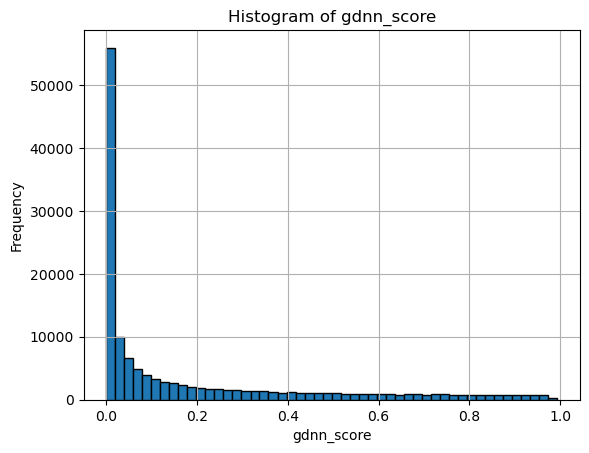

In [79]:
plot_histogram(df_bkg_reco, 'gdnn_score')

In [80]:


# Add a truth label (1 for signal, 0 for background)
df_sig_reco['label'] = 1
df_bkg_reco['label'] = 0


# Combine into a single evaluation dataset
df_eval_reco = pd.concat([df_sig_reco, df_bkg_reco], ignore_index=True)


Evaluating Signal Efficiency vs system_pt using 'tdnn_score' (Weighted=True)...
 -> Threshold for 0.10% Background Acceptance: 0.9805
 -> Threshold for 0.50% Background Acceptance: 0.9645


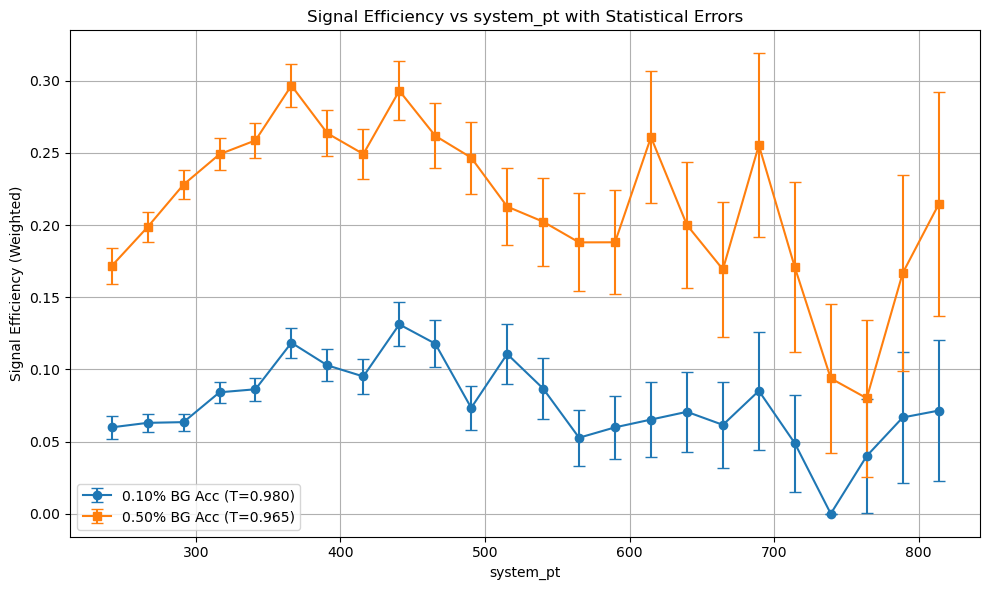

{0.001: 0.98046875, 0.005: 0.9645288085805015}

In [55]:
plot_efficiency_vs_feature(df_test[df_test['label']==1], df_test[df_test['label']==0],'tdnn_score', 'system_pt', weighted = True)

Evaluating Background Rejection vs system_pt using 'tdnn_score' (Weighted=True)...
 -> Threshold for 20.00% Signal Efficiency: 0.9688
 -> Threshold for 40.00% Signal Efficiency: 0.9355
 -> Threshold for 60.00% Signal Efficiency: 0.8657


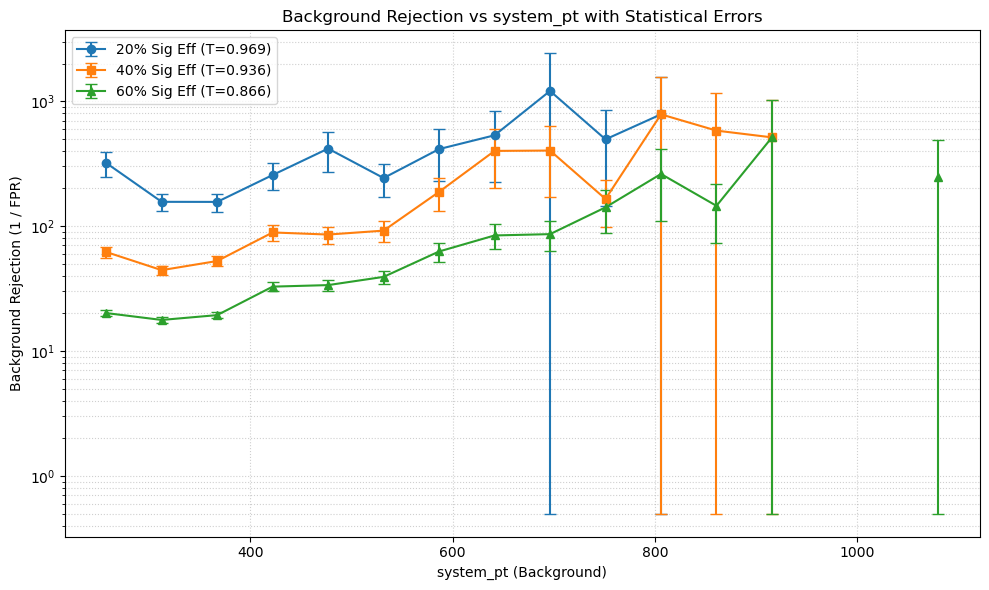

{0.2: 0.96875, 0.4: 0.935546875, 0.6: 0.86572265625}

In [56]:
plot_bkg_rejection_vs_feature(df_test[df_test['label']==1], df_test[df_test['label']==0],'tdnn_score', 'system_pt', tpr_thresholds=[0.2, 0.4, 0.6], weighted = True)

Evaluating Background Rejection vs system_pt using 'dnn_score' (Weighted=True)...
 -> Threshold for 20.00% Signal Efficiency: 0.9663
 -> Threshold for 40.00% Signal Efficiency: 0.9312
 -> Threshold for 60.00% Signal Efficiency: 0.8574


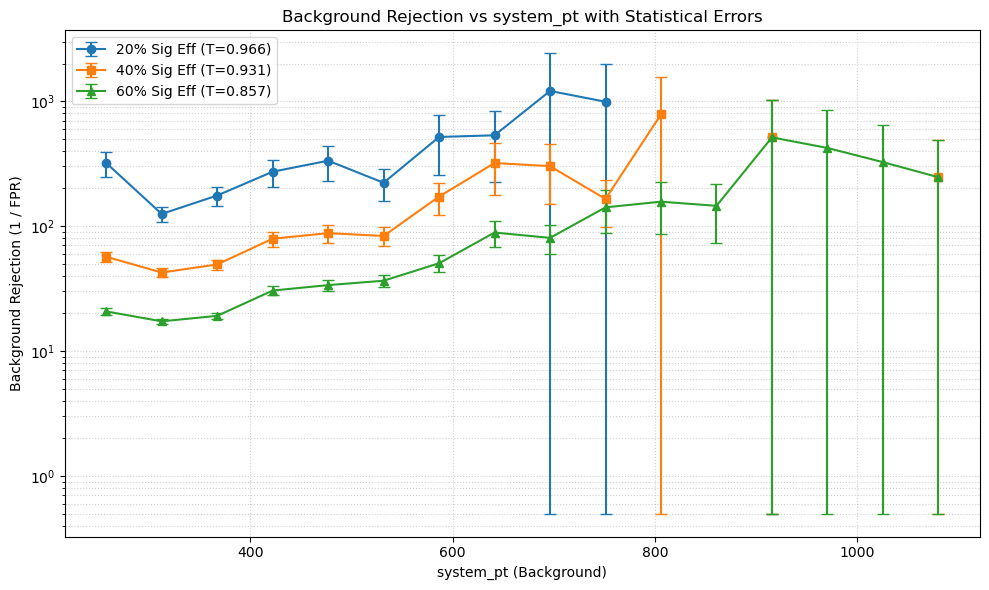

{0.2: 0.96630859375, 0.4: 0.93115234375, 0.6: 0.857421875}

In [58]:
plot_bkg_rejection_vs_feature(df_test[df_test['label']==1], df_test[df_test['label']==0],'dnn_score', 'system_pt', tpr_thresholds=[0.2, 0.4, 0.6], weighted = True)

In [21]:
print_nan_counts(df_eval_reco)

No NaN values found in any column.


Series([], dtype: int64)

In [45]:
df_reco_alone = pl.read_parquet("test_scored_alone.parquet").to_pandas()

In [19]:
df_test = pl.read_parquet("tdnn_combined_results/test_df.parquet").to_pandas()

In [26]:
print(df_test_truth.columns)

Index(['MET', 'METPhi', 'fatJetPt', 'fatJetEta', 'fatJetPhi', 'fatJetM',
       'fatJetD2', 'numOfInDetTracks_inFJCone', 'numOfFatJets', 'jet1Pt',
       ...
       'event_index', '__index_level_0__', 'weight', 'label', 'dnn_score',
       'gnn_score', 'gdnn_score', 't_score', 'tdnn_score', 'deepset_score'],
      dtype='object', length=249)


Comparing models: deepset_score, gnn_score, t_score...


/tmp/ipykernel_172/2490092936.py:119: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


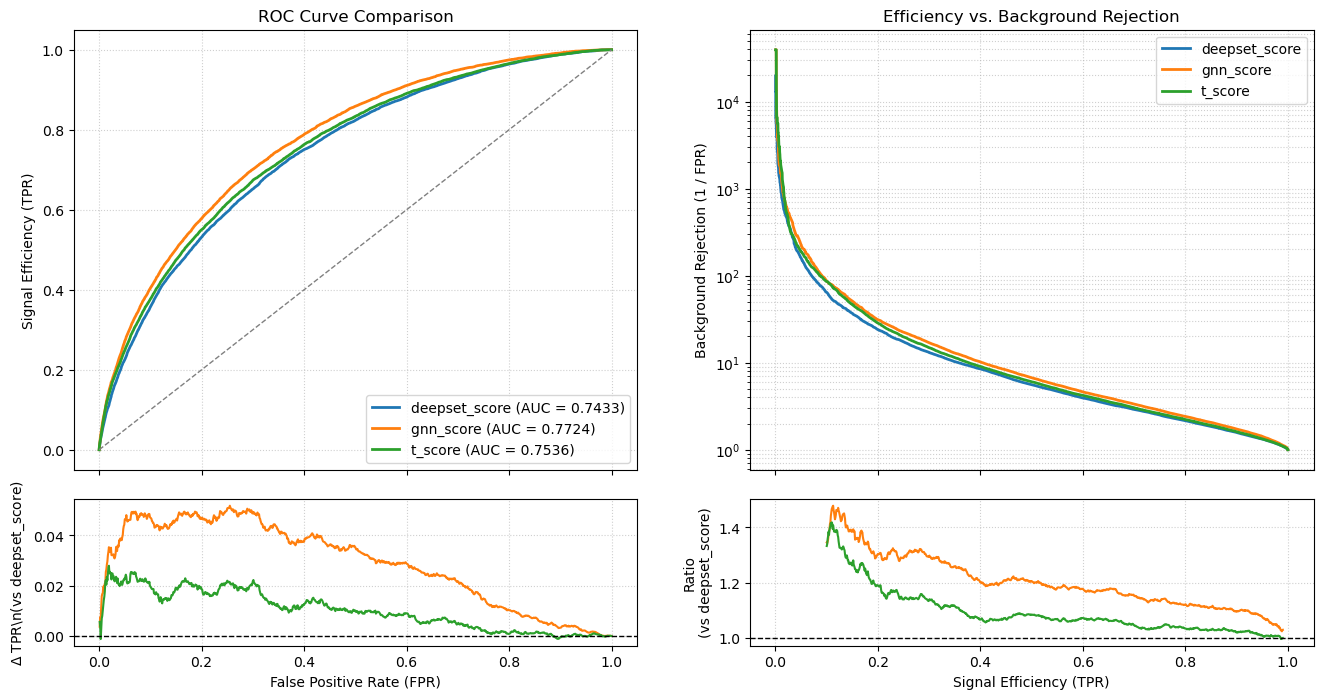

In [59]:
plot_model_comparison(df_reco_alone, ['deepset_score','gnn_score', 't_score'])

Comparing models: dnn_score, tdnn_score, gdnn_score...


/tmp/ipykernel_172/2490092936.py:119: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


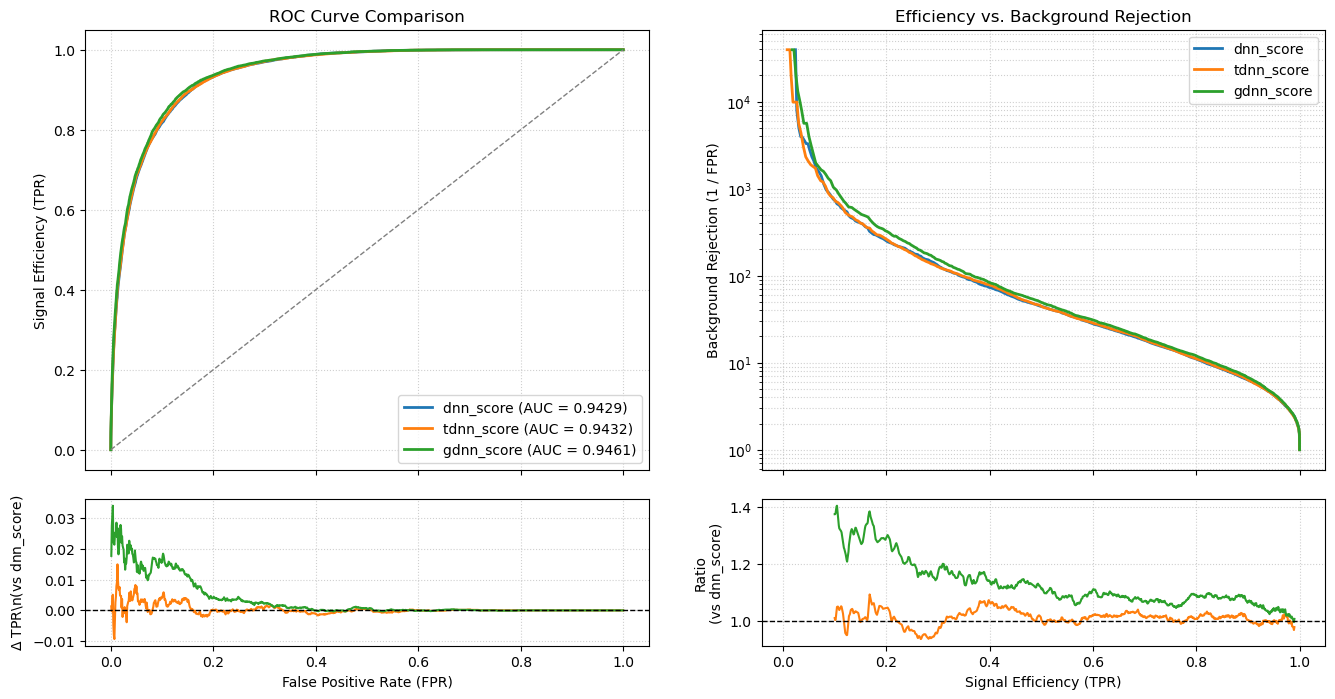

In [42]:
plot_model_comparison(df_test, ['dnn_score','tdnn_score','gdnn_score'])

Comparing models: deepset_score, gnn_score, t_score...


/tmp/ipykernel_172/2490092936.py:119: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


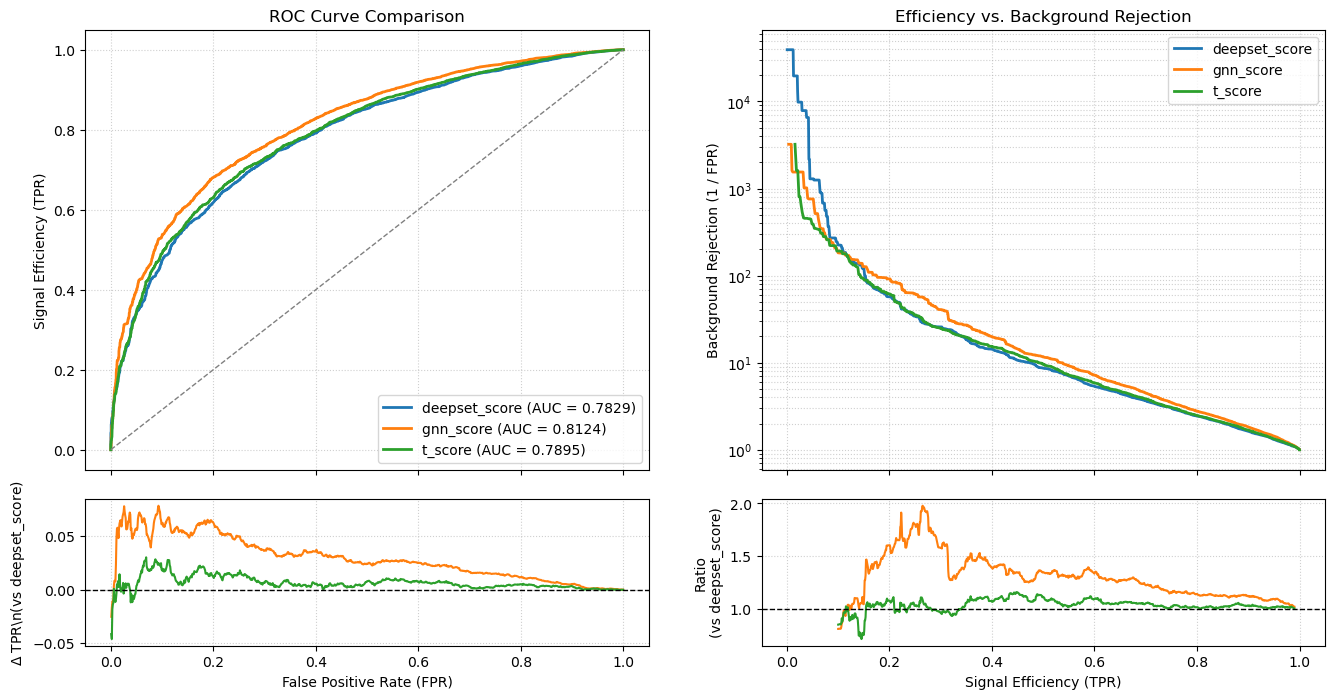

In [43]:
plot_model_comparison(df_test_truth, ['deepset_score','gnn_score', 't_score'])

Comparing models: dnn_score, tdnn_score, gdnn_score...


/tmp/ipykernel_172/679826911.py:118: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


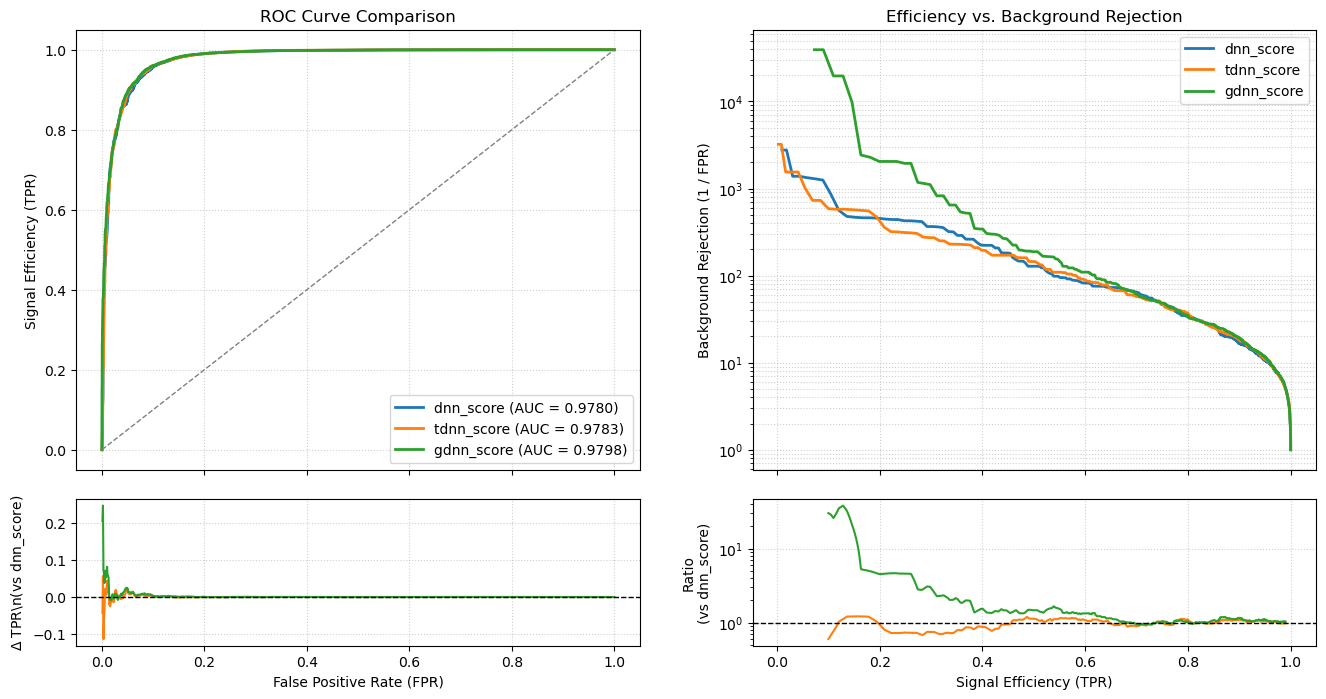

In [38]:
plot_model_comparison(df_test_truth, ['dnn_score','tdnn_score','gdnn_score'])

In [15]:


# Add a truth label (1 for signal, 0 for background)
df_sig_truth['label'] = 1
df_bkg_truth['label'] = 0


# Combine into a single evaluation dataset
df_eval_truth = pd.concat([df_sig_truth, df_bkg_truth], ignore_index=True)


In [50]:


# Add a truth label (1 for signal, 0 for background)
df_sig_reco_old['label'] = 1
df_bkg_reco_old['label'] = 0


# Combine into a single evaluation dataset
df_eval_reco_old = pd.concat([df_sig_reco_old, df_bkg_reco_old], ignore_index=True)


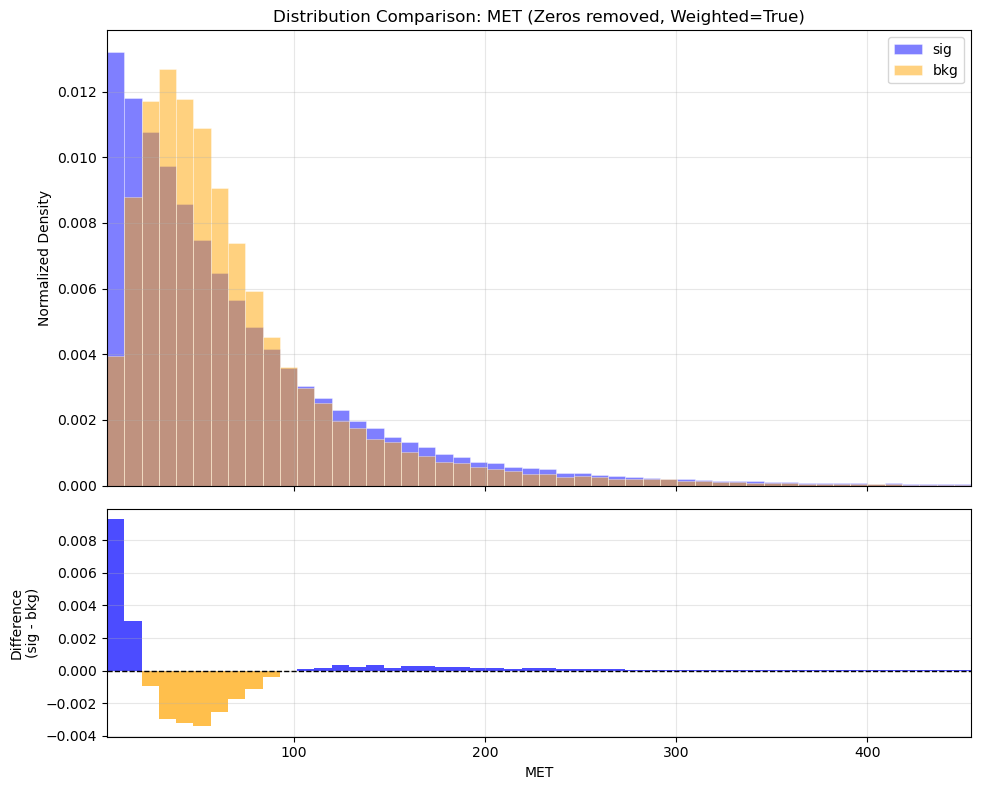

In [20]:
plot_histogram_diffs(df_sig_truth, df_bkg_truth, ['MET'], weighted = True, df1_label = "sig", df2_label = "bkg")

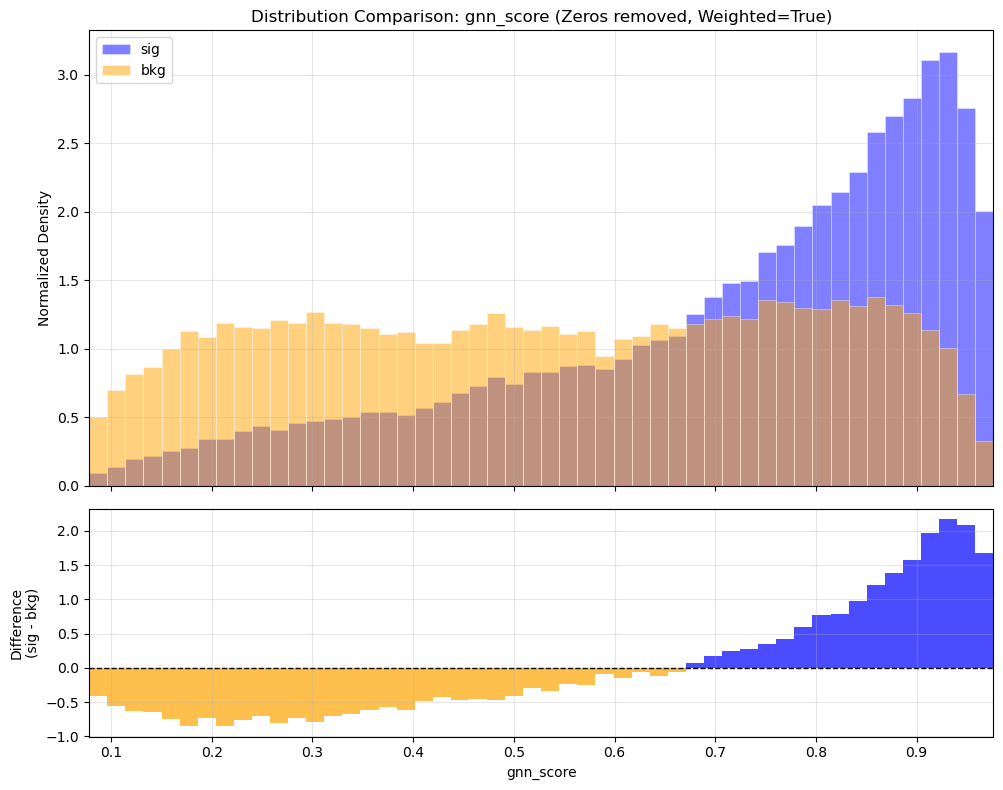

In [121]:
plot_histogram_diffs(df_sig_reco[df_sig_reco['dnn_score']>0.5], df_bkg_reco[df_bkg_reco['dnn_score']>0.5], ['gnn_score'], weighted = True, 
                     df1_label = "sig", df2_label = "bkg")

In [88]:
df_sig_reco_hard = pl.read_parquet("gdnn_combined_results/df_sig_reco_mu_weighted_scored_special.parquet").to_pandas()
df_bkg_reco_hard = pl.read_parquet("gdnn_combined_results/df_bkg_reco_mu_weighted_scored_special.parquet").to_pandas()

In [181]:
df_sig_reco_cut['eta_diff']=df_sig_reco_cut['fj_track1Eta']-df_sig_reco_cut['muonEta']

In [178]:
df_sig_reco_zoom=df_sig_reco_cut[(df_sig_reco_cut['fj_track1Eta']<0.35) & (df_sig_reco_cut['fj_track1Eta']>0.33)]

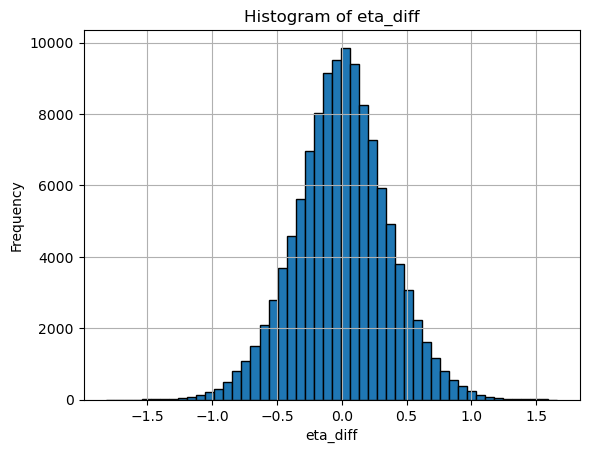

In [182]:
plot_histogram(df_sig_reco_cut, 'eta_diff')

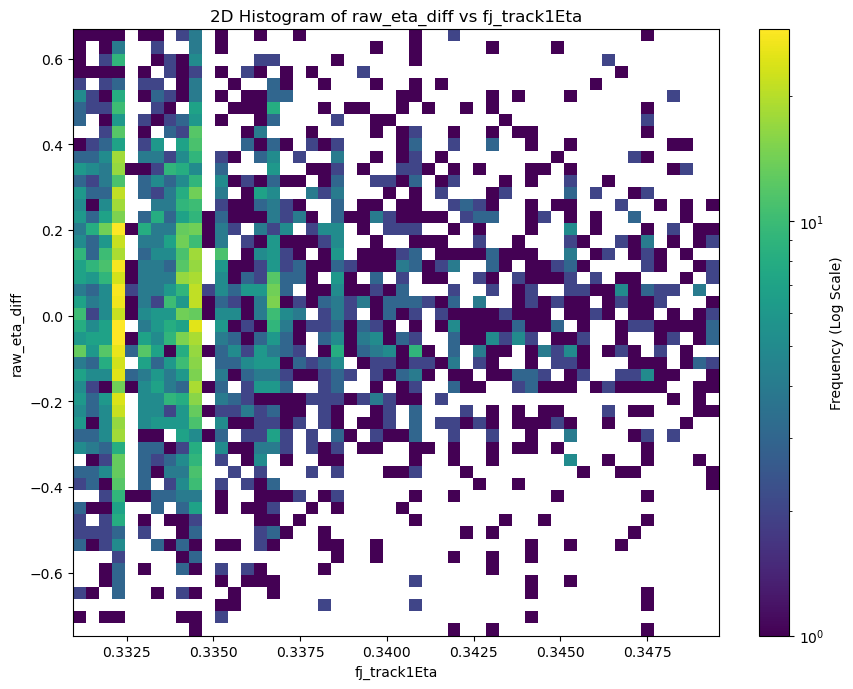

In [176]:
plot_2d_histogram(df_sig_reco_zoom, 'fj_track1Eta', 'raw_eta_diff', log_z=True)

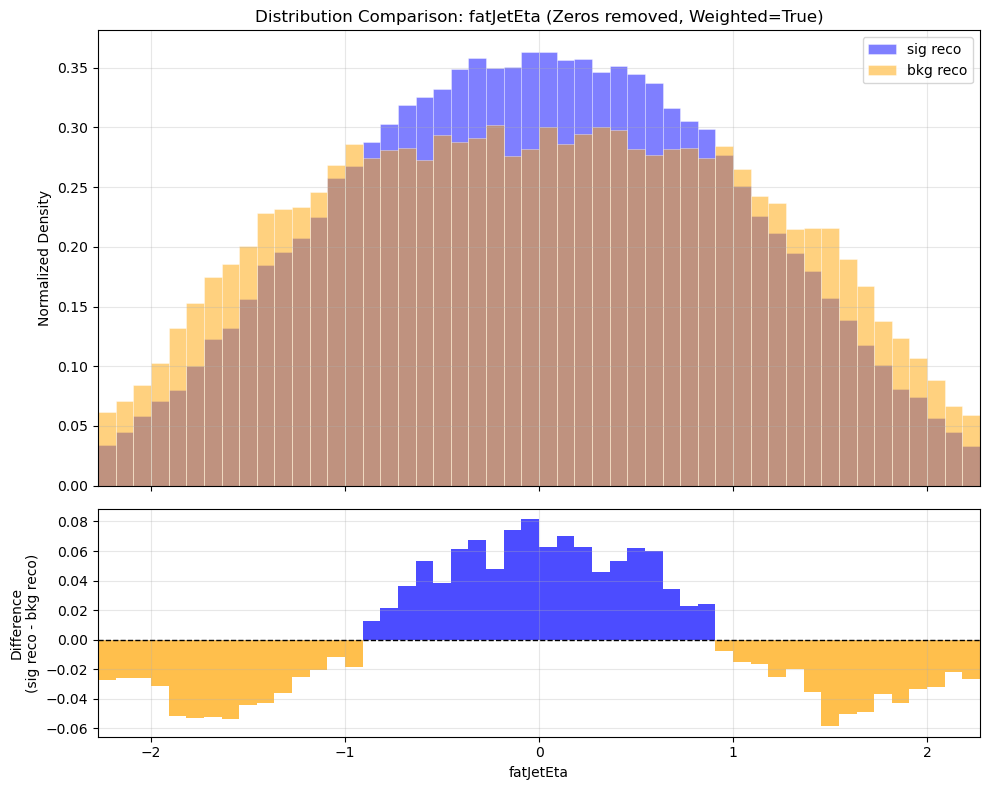

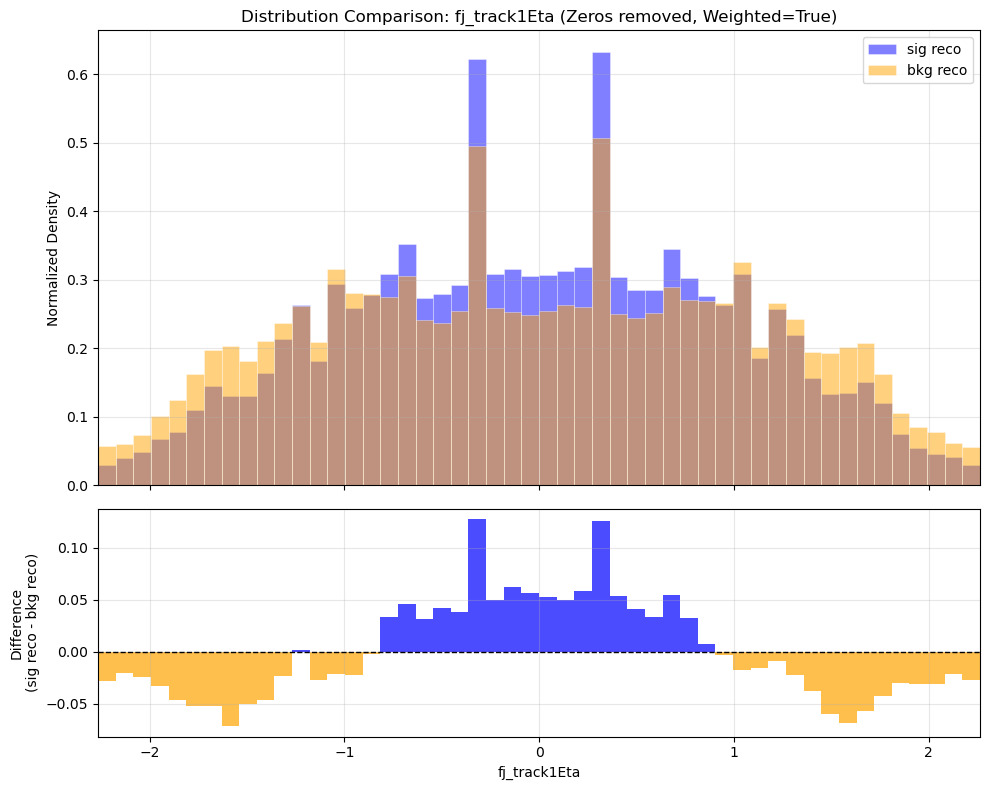

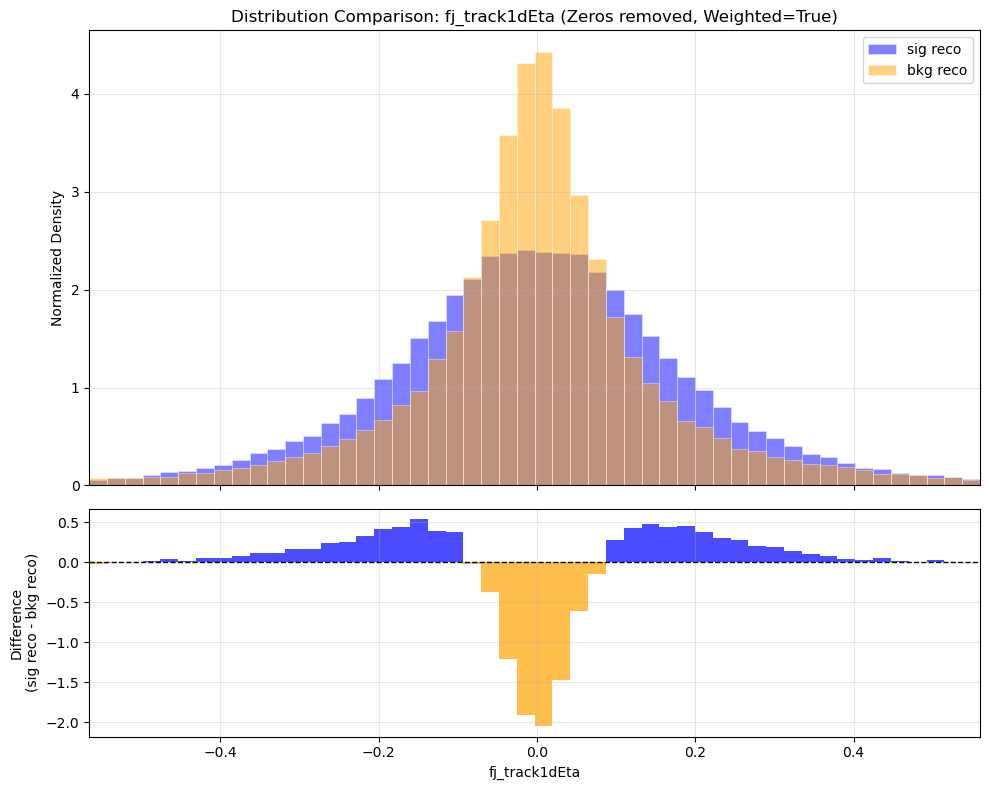

In [143]:
plot_histogram_diffs(df_sig_reco_cut, df_bkg_reco_cut, ['fatJetEta', 'fj_track1Eta', 'fj_track1dEta'], weighted = True, df1_label = "sig reco", df2_label = "bkg reco")

Evaluating Signal Efficiency vs fatJetM using 'dnn_score' (Weighted=False)...
 -> Threshold for 0.10% Background Acceptance: 0.9795
 -> Threshold for 0.50% Background Acceptance: 0.9600


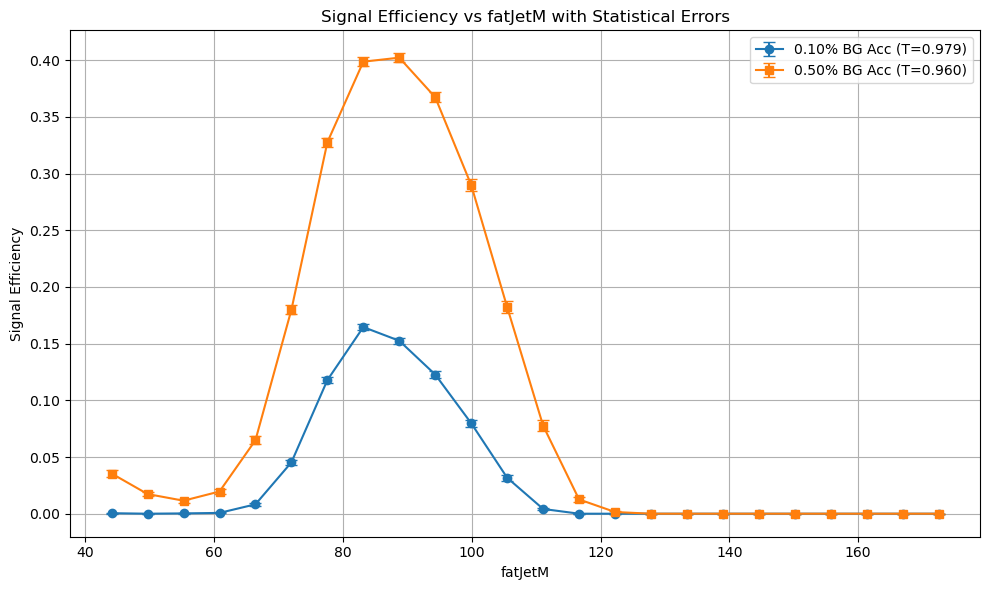

{0.001: 0.9794921875, 0.005: 0.9599609375}

In [46]:
plot_efficiency_vs_feature(df_sig_reco, df_bkg_reco, 'dnn_score', 'fatJetM')

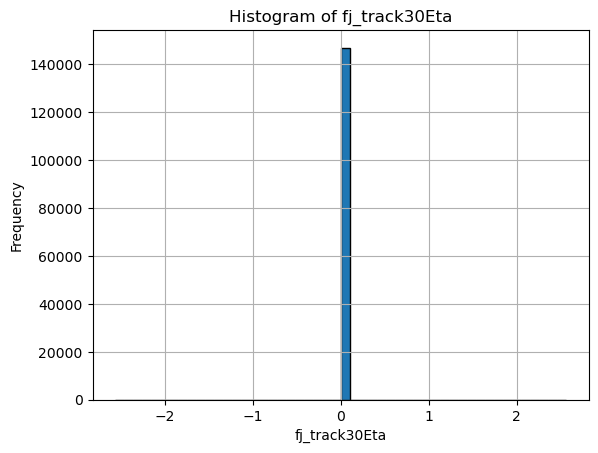

In [62]:
plot_histogram(df_sig_reco, 'fj_track30Eta')

In [94]:
def ensemble_scores(df): 
    df['ensemble_avg_score'] = (df['dnn_score'] + df['gnn_score']) / 2
    
    df['ensemble_final_vote'] = (df['ensemble_avg_score'] > 0.5).astype(int)

In [78]:
df_sig_reco_sub['label'] = 1
df_bkg_reco_sub['label'] = 0
df_eval_reco_sub = pd.concat([df_sig_reco_sub, df_bkg_reco_sub], ignore_index=True)

Comparing 'dnn_score' vs 'gdnn_score'...


/tmp/ipykernel_170/49719945.py:128: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


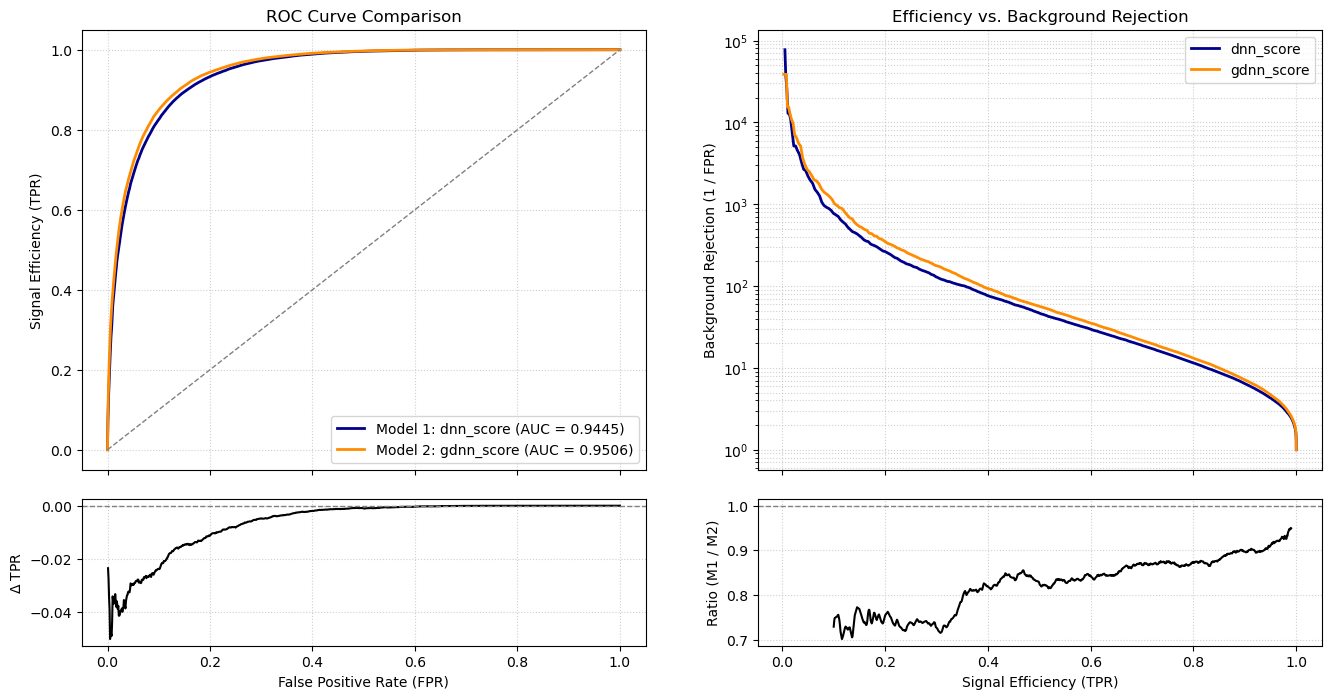

In [58]:
plot_model_comparison(df_eval_reco_old, 'dnn_score','gdnn_score')

In [29]:
df_sig_reco['weight'] = len(df_sig_reco)+len(df_bkg_reco)/2/len(df_sig_reco)
df_bkg_reco['weight'] = len(df_sig_reco)+len(df_bkg_reco)/2/len(df_bkg_reco)

In [113]:
df_bg280_truth = df_bg280_truth[df_bg280_truth['muon_fatjet_dr']<1]
df_bg500_truth = df_bg500_truth[df_bg500_truth['muon_fatjet_dr']<1]
df_bg1000_truth = df_bg1000_truth[df_bg1000_truth['muon_fatjet_dr']<1]

In [122]:
df_bg280_truth = df_bg280_truth[df_bg280_truth['muonPt']>20]
df_bg500_truth = df_bg500_truth[df_bg500_truth['muonPt']>20]
df_bg1000_truth = df_bg1000_truth[df_bg1000_truth['muonPt']>20]

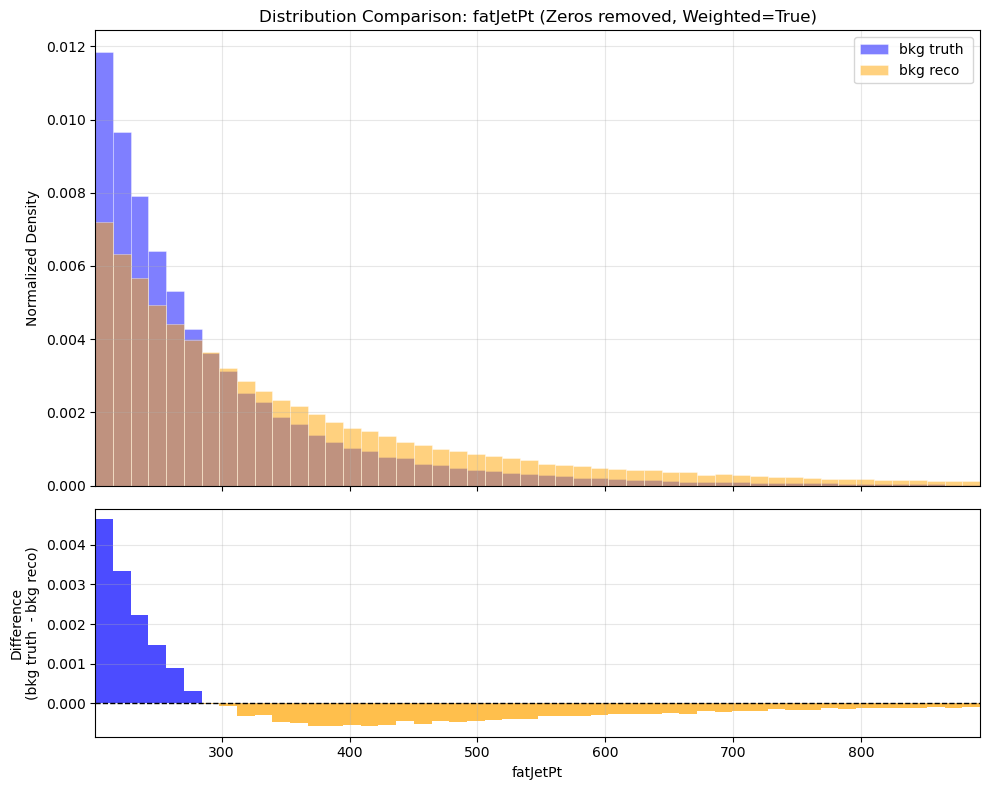

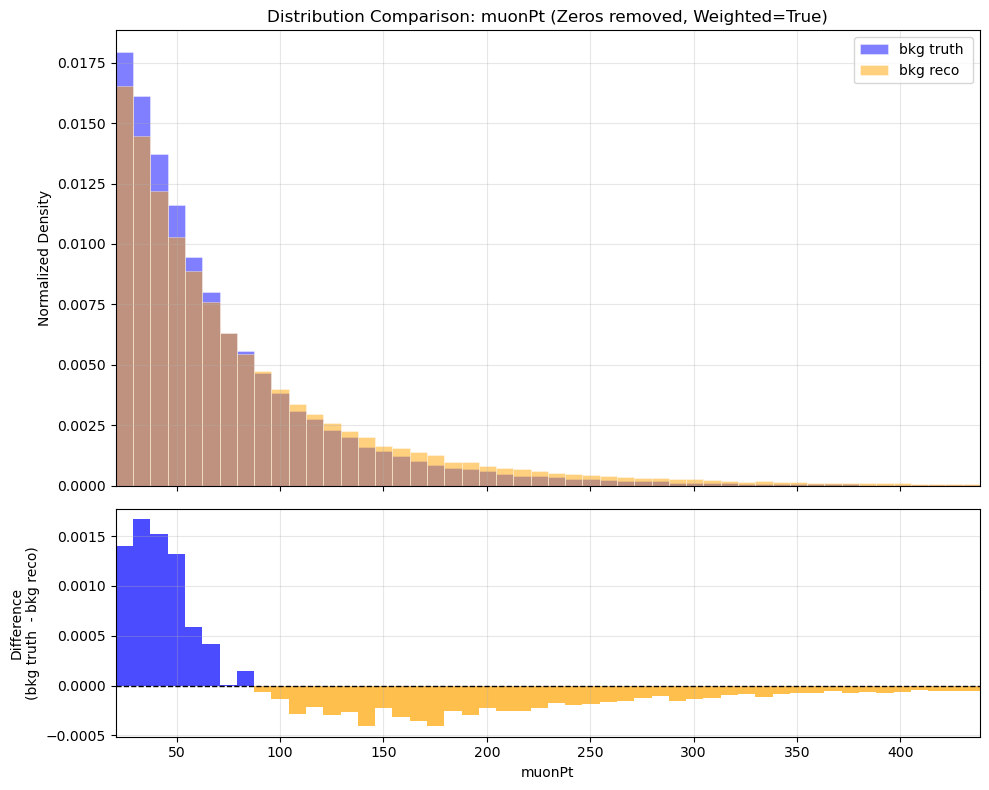

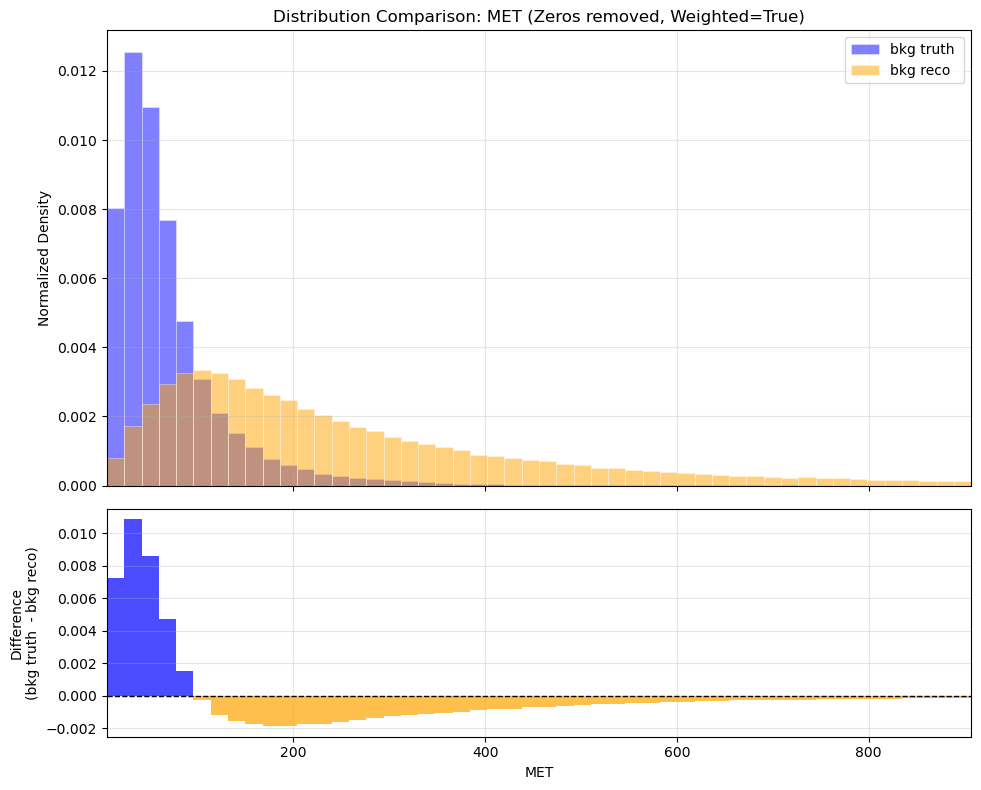

In [30]:
plot_histogram_diffs(df_sig_, df_bkg_reco, 
                     my_dnn_features, df1_label = "bkg truth ", df2_label = "bkg reco", weighted = True)

Evaluating Signal Efficiency vs fatJetM using 'gnn_score' (Weighted=True)...
 -> Threshold for 0.10% Background Acceptance: 0.9663
 -> Threshold for 0.50% Background Acceptance: 0.9438


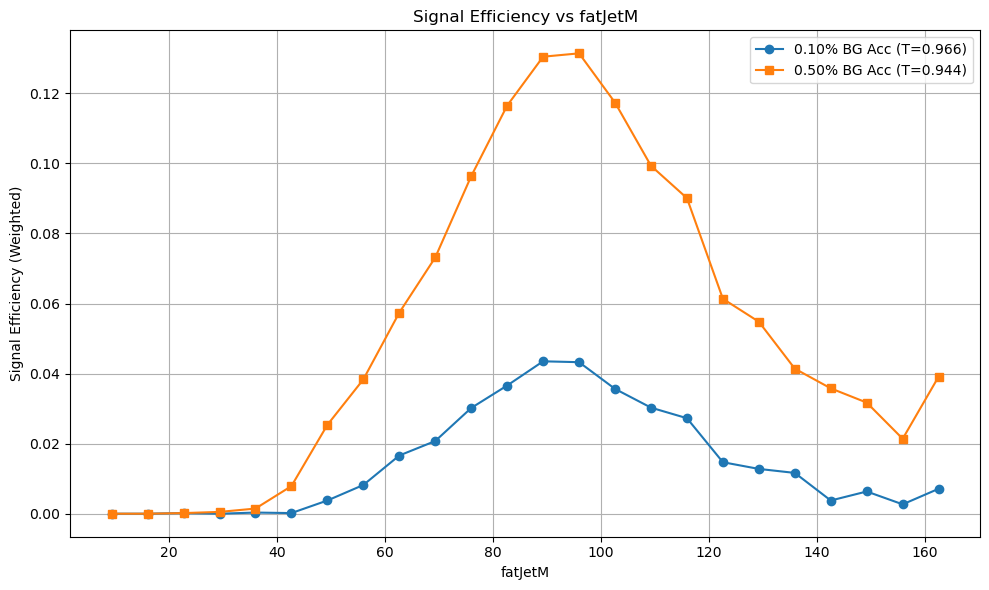

In [146]:
thrds = plot_efficiency_vs_feature(df_sig_reco, df_bkg_reco, "gnn_score", "fatJetM", weighted=True)

In [128]:
my_dnn_features = [
    # Global / Track Counts
    'numOfInDetTracks_inFJCone', 'fatJetD2',
    
    # Muon Base Kinematics (Keeping Eta as the spatial reference point)
    'muonPt', 'muonEta', 
    
    # FatJet Base Kinematics
    'fatJetPt', 'fatJetM', 'fatJetEta', 
    
    # Small Jets Base Kinematics
    'jet1Pt', 'jet1M','jet2Pt', 'jet2M',
    
    # MET Base
    'MET',
    
    # Pre-existing Relative Geometries
    'muon_fatjet_dr', 'muon_fatjet_deta', 'muon_fatjet_dphi',
    
    # Newly Engineered Relative Geometries
    'muon_jet1_dr', 'muon_jet1_deta', 'muon_jet1_dphi',
    
    'muon_jet2_dr', 'muon_jet2_deta', 'muon_jet2_dphi',
    
    'muon_MET_dphi', 'fatjet_MET_dphi'
]

In [95]:
df_to_process = [
    df_sig_truth, df_bkg_truth, df_sig_reco, df_bkg_reco, df_eval_truth, df_eval_reco, df_sig_reco_hard, df_bkg_reco_hard
]
for df in df_to_process:
    ensemble_scores(df)

In [35]:
def plot_model_comparison(df, score_col_1, score_col_2, label_col='label', weight_col='weight'):
    """
    Plots overlaid ROC curves and Efficiency vs Rejection curves for two models,
    along with their differences/ratios in bottom panels.
    """
    print(f"Comparing '{score_col_1}' vs '{score_col_2}'...")
    
    y_true = df[label_col].values
    weights = df[weight_col].values if weight_col in df.columns else None

    # Get predictions
    y_score1 = df[score_col_1].values
    y_score2 = df[score_col_2].values

    # Calculate ROC metrics
    fpr1, tpr1, _ = roc_curve(y_true, y_score1, sample_weight=weights)
    fpr2, tpr2, _ = roc_curve(y_true, y_score2, sample_weight=weights)

    auc1 = auc(fpr1, tpr1)
    auc2 = auc(fpr2, tpr2)

    # Setup the figure with GridSpec (Top panel 3x larger than bottom panel)
    fig = plt.figure(figsize=(16, 8))
    gs = gridspec.GridSpec(2, 2, height_ratios=[3, 1], hspace=0.1)

    # ==========================================
    # Panel Column 1: ROC Curves (TPR vs FPR)
    # ==========================================
    ax_roc_main = fig.add_subplot(gs[0, 0])
    ax_roc_diff = fig.add_subplot(gs[1, 0], sharex=ax_roc_main)

    # --- Main ROC ---
    ax_roc_main.plot(fpr1, tpr1, lw=2, label=f'Model 1: {score_col_1} (AUC = {auc1:.4f})', color='darkblue')
    ax_roc_main.plot(fpr2, tpr2, lw=2, label=f'Model 2: {score_col_2} (AUC = {auc2:.4f})', color='darkorange')
    ax_roc_main.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
    ax_roc_main.set_ylabel('Signal Efficiency (TPR)')
    ax_roc_main.set_title('ROC Curve Comparison')
    ax_roc_main.legend(loc='lower right')
    ax_roc_main.grid(True, linestyle=':', alpha=0.6)
    
    # Hide x-axis labels on the main plot to prevent overlapping with the diff plot
    plt.setp(ax_roc_main.get_xticklabels(), visible=False)

    # --- ROC Difference (Model 1 - Model 2) ---
    # Create a common FPR grid and interpolate TPR values
    fpr_grid = np.linspace(0.001, 1.0, 1000)
    tpr1_interp = np.interp(fpr_grid, fpr1, tpr1)
    tpr2_interp = np.interp(fpr_grid, fpr2, tpr2)
    roc_diff = tpr1_interp - tpr2_interp

    ax_roc_diff.plot(fpr_grid, roc_diff, color='black', lw=1.5)
    ax_roc_diff.axhline(0, color='gray', linestyle='--', lw=1)
    ax_roc_diff.set_xlabel('False Positive Rate (FPR)')
    ax_roc_diff.set_ylabel(r'$\Delta$ TPR', fontsize=10)
    ax_roc_diff.grid(True, linestyle=':', alpha=0.6)

    # ==========================================
    # Panel Column 2: Efficiency vs Background Rejection
    # ==========================================
    ax_rej_main = fig.add_subplot(gs[0, 1])
    ax_rej_diff = fig.add_subplot(gs[1, 1], sharex=ax_rej_main)

    # Safely calculate rejection (1 / FPR)
    with np.errstate(divide='ignore'):
        rej1 = np.where(fpr1 > 0, 1.0 / fpr1, np.nan)
        rej2 = np.where(fpr2 > 0, 1.0 / fpr2, np.nan)

    # --- Main Eff vs Rej ---
    ax_rej_main.plot(tpr1, rej1, lw=2, label=f'{score_col_1}', color='darkblue')
    ax_rej_main.plot(tpr2, rej2, lw=2, label=f'{score_col_2}', color='darkorange')
    ax_rej_main.set_yscale('log')
    ax_rej_main.set_ylabel('Background Rejection (1 / FPR)')
    ax_rej_main.set_title('Efficiency vs. Background Rejection')
    ax_rej_main.legend(loc='upper right')
    ax_rej_main.grid(True, which="both", linestyle=':', alpha=0.6)

    plt.setp(ax_rej_main.get_xticklabels(), visible=False)

    # --- Eff vs Rej Ratio (Model 1 / Model 2) ---
    # Create a common TPR grid and interpolate Rejection values
    # We restrict to 0.1 - 0.99 to avoid massive volatility at the extreme tails
    tpr_grid = np.linspace(0.1, 0.99, 1000)
    rej1_interp = np.interp(tpr_grid, tpr1, rej1)
    rej2_interp = np.interp(tpr_grid, tpr2, rej2)
    
    # Calculate ratio, masking out NaN values or division by zero safely
    with np.errstate(divide='ignore', invalid='ignore'):
        rej_ratio = np.divide(rej1_interp, rej2_interp)
        rej_ratio = np.nan_to_num(rej_ratio, nan=1.0, posinf=1.0, neginf=1.0)

    ax_rej_diff.plot(tpr_grid, rej_ratio, color='black', lw=1.5)
    ax_rej_diff.axhline(1, color='gray', linestyle='--', lw=1)
    ax_rej_diff.set_xlabel('Signal Efficiency (TPR)')
    ax_rej_diff.set_ylabel('Ratio (M1 / M2)', fontsize=10)
    
    # Optional: Log scale for the ratio if the variations are extreme
    # ax_rej_diff.set_yscale('log') 
    
    ax_rej_diff.grid(True, linestyle=':', alpha=0.6)

    plt.tight_layout()
    plt.show()


In [ ]:
plot_histogram_diff(df_sig_reco, df_bkg_reco,['

In [104]:
def simple(df_eval):    
    # np.where(condition, value_if_true, value_if_false)
    df_eval['simple_score'] = np.where(
        df_eval['dnn_score'] > 0.5,  # The condition
        df_eval['dnn_score'],        # What to do if True
        df_eval['gnn_score']         # What to do if False
    )

In [106]:
for df in df_to_process:
    simple(df)

Comparing 'dnn_score' vs 'gdnn_score'...


/tmp/ipykernel_182/3698266579.py:101: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


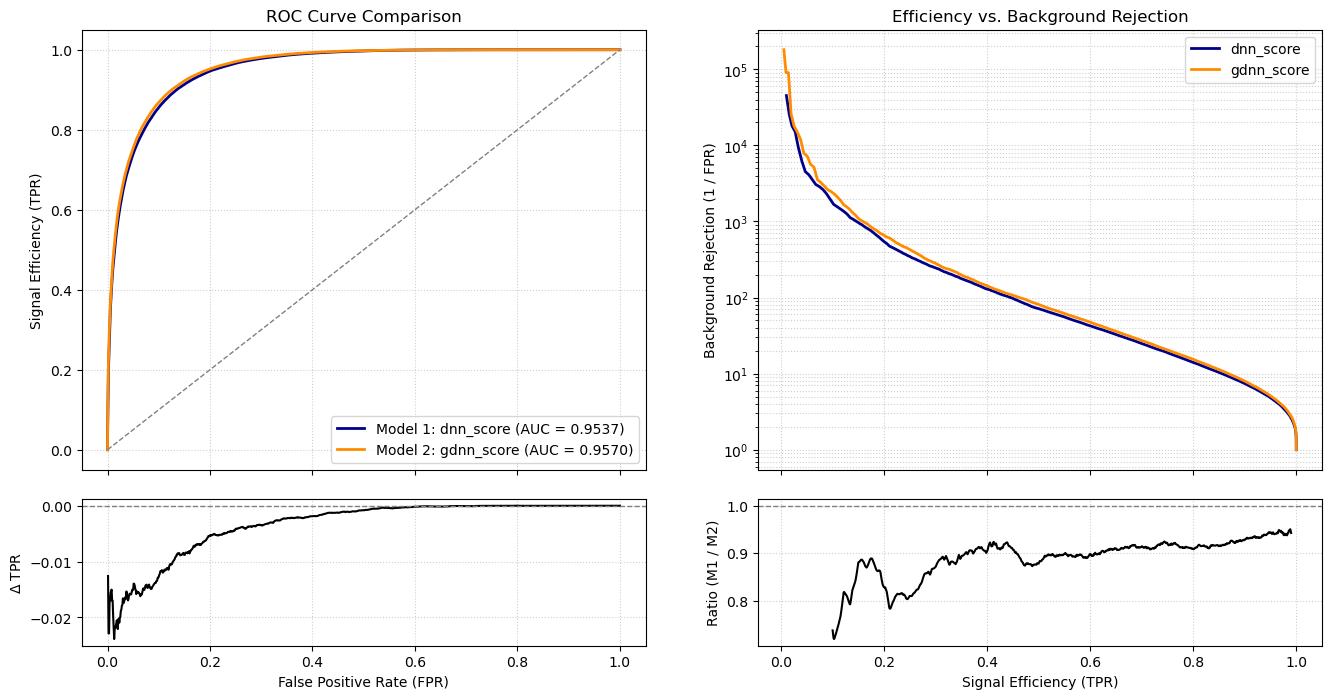

In [143]:

# --- Execution ---
# Let's say your other model's score is saved under 'gnn_score' 
# and the new combined model is 'gdnn_score'.
plot_model_comparison(
    df=df_eval_reco_sub, 
    score_col_1='dnn_score', 
    score_col_2='gdnn_score', 
    label_col='label', 
    weight_col='weight' # remove if your dataset isn't physically weighted
)

In [8]:
for i in range(1, 31):
    track_eta = f"fj_track{i}Eta"
    track_phi = f"fj_track{i}Phi"
    track_deta = f"fj_track{i}dEta"
    track_dphi = f"fj_track{i}dPhi"
    track_dr = f"fj_track{i}dR"
    df_sig_reco[track_deta] = np.asarray(df_sig_reco["fatJetEta"])- np.asarray(df_sig_reco[track_eta])
    df_sig_reco[track_dphi] = delta_phi(df_sig_reco["fatJetPhi"], df_sig_reco[track_phi])
    df_sig_reco[track_dr] = np.sqrt(df_sig_reco[track_deta]**2 + df_sig_reco[track_dphi]**2)
    df_bkg_reco[track_deta] = np.asarray(df_bkg_reco["fatJetEta"])- np.asarray(df_bkg_reco[track_eta])
    df_bkg_reco[track_dphi] = delta_phi(df_bkg_reco["fatJetPhi"], df_bkg_reco[track_phi])
    df_bkg_reco[track_dr] = np.sqrt(df_bkg_reco[track_deta]**2 + df_bkg_reco[track_dphi]**2)

In [10]:
df_sig_truth = pl.read_parquet("df_sig_truth_flat.parquet").to_pandas()

In [9]:
df_bg280_truth = pl.read_parquet("df_bg280_truth_flat.parquet").to_pandas()
df_bg500_truth = pl.read_parquet("df_bg500_truth_flat.parquet").to_pandas()
df_bg1000_truth = pl.read_parquet("df_bg1000_truth_flat.parquet").to_pandas()


In [46]:
df_sig_truth = df_sig_truth[df_sig_truth['muonPt']>20]

In [10]:
dfs = [
       #df_sig_truth,
       df_bg280_truth, df_bg500_truth, df_bg1000_truth]

for df in dfs:
    cols_to_scale = [
        col for col in df.columns 
        if 'pt' in col.lower() or col.endswith('M') or col.endswith('m') or col == 'MET'
    ]
    df[cols_to_scale] /= 1000.0

In [11]:
df_bg280_truth['weight']=72.1
df_bg500_truth['weight']=15
df_bg1000_truth['weight']=1.23

In [48]:
df_sig_truth['weight']=1

In [49]:
df_sig_truth.to_parquet("df_sig_truth_mu.parquet")

In [ ]:
df_sig_reco.to_parquet("df_sig_reco_cleaned_fj200.parquet")
df_bkg_reco.to_parquet("df_bkg_reco_cleaned_fj200.parquet")

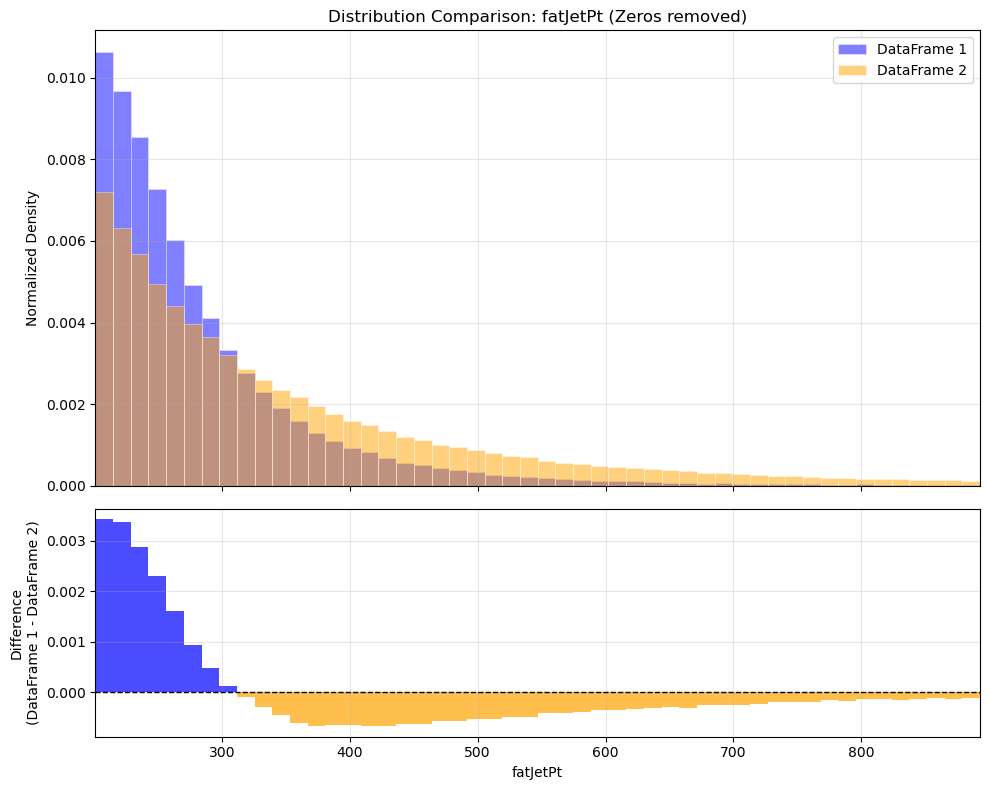

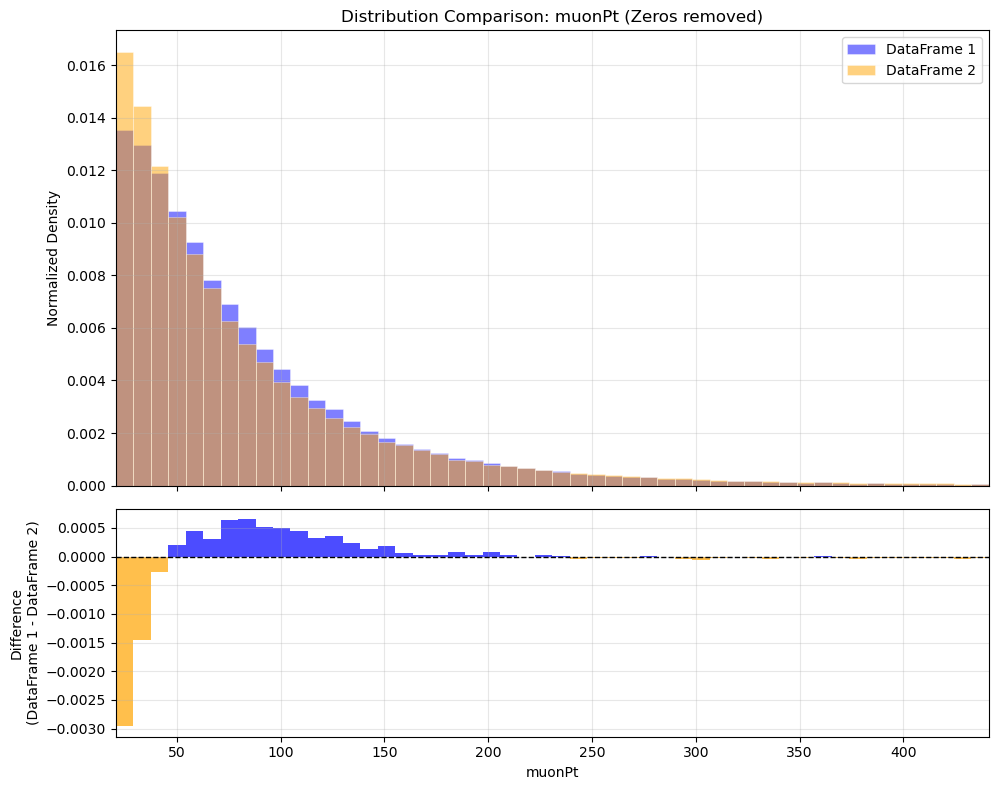

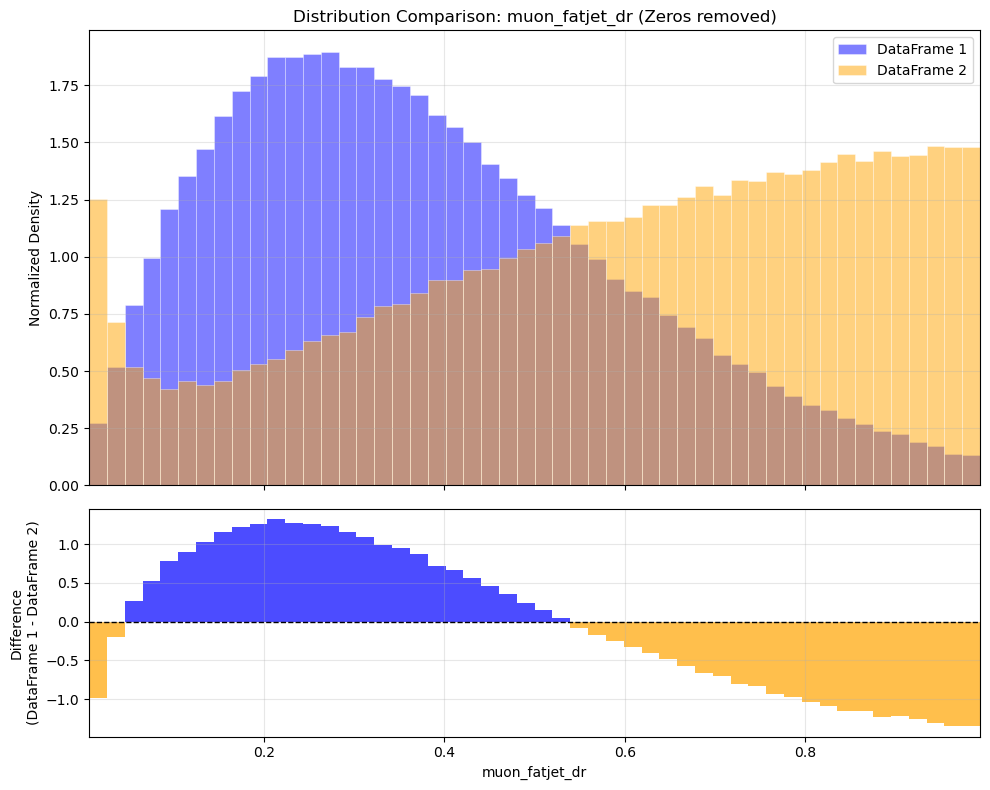

In [63]:
plot_histogram_diffs(df_sig_reco, df_bkg_reco, ['fatJetPt', 'muonPt', 'muon_fatjet_dr'])



In [61]:
df_sig_reco = df_sig_reco[df_sig_reco['fatJetPt']>200]

In [62]:
df_bkg_reco = df_bkg_reco[df_bkg_reco['fatJetPt']>200]

In [12]:
df_bkg_truth = pd.concat([df_bg280_truth, df_bg500_truth, df_bg1000_truth])

In [13]:
df_bkg_truth_copy=df_bkg_truth.copy()

In [14]:
df_bkg_truth = df_bkg_truth[df_bkg_truth['muon_fatjet_dr']<1]

In [56]:
df_sig_truth = df_sig_truth[df_sig_truth['muon_fatjet_dr']<1]

In [59]:
df_sig_reco = df_sig_reco[df_sig_reco['muon_fatjet_dr']<1]

In [60]:
df_bkg_reco = df_bkg_reco[df_bkg_reco['muon_fatjet_dr']<1]

In [18]:
df_bkg_truth = df_bkg_truth[df_bkg_truth['muonPt']>20]

In [31]:
df_bkg_truth = df_bkg_truth[df_bkg_truth['lepId'].abs() == 13]

In [32]:
df_bkg_truth.to_parquet("df_bkg_truth_mu.parquet")

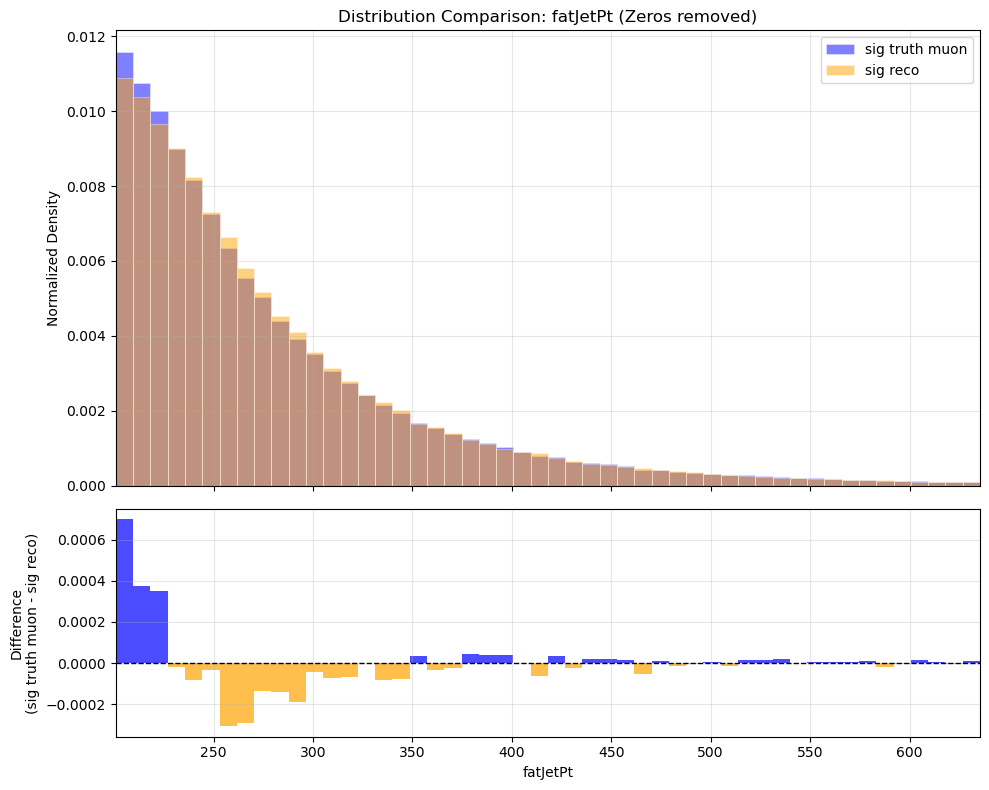

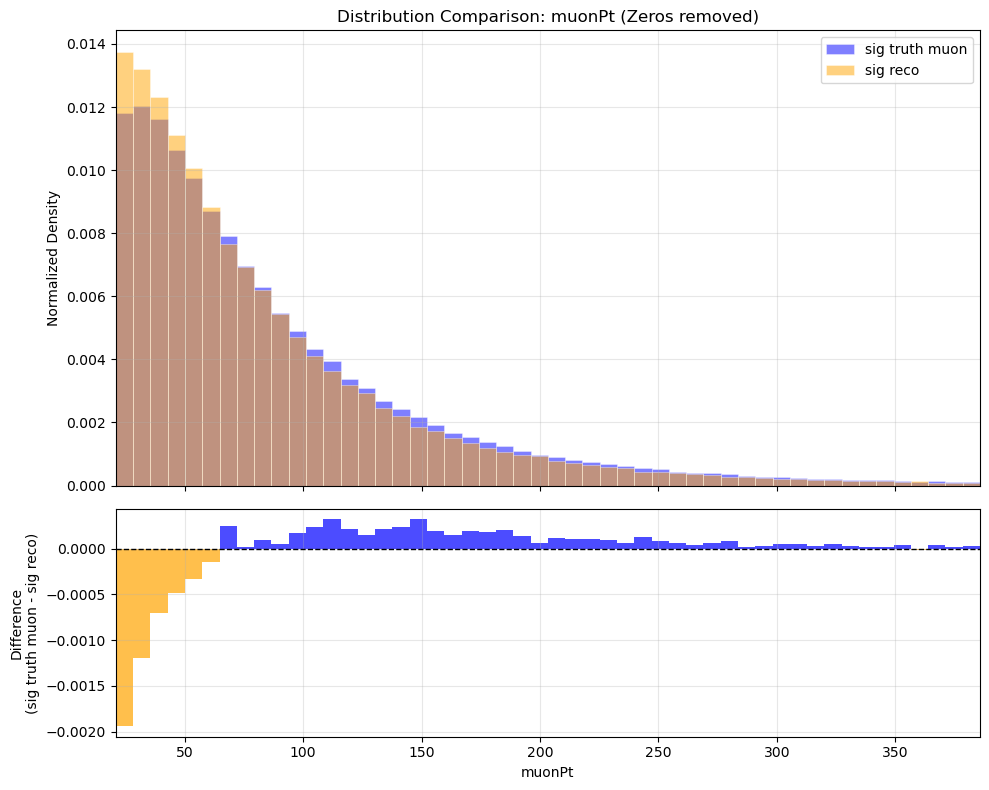

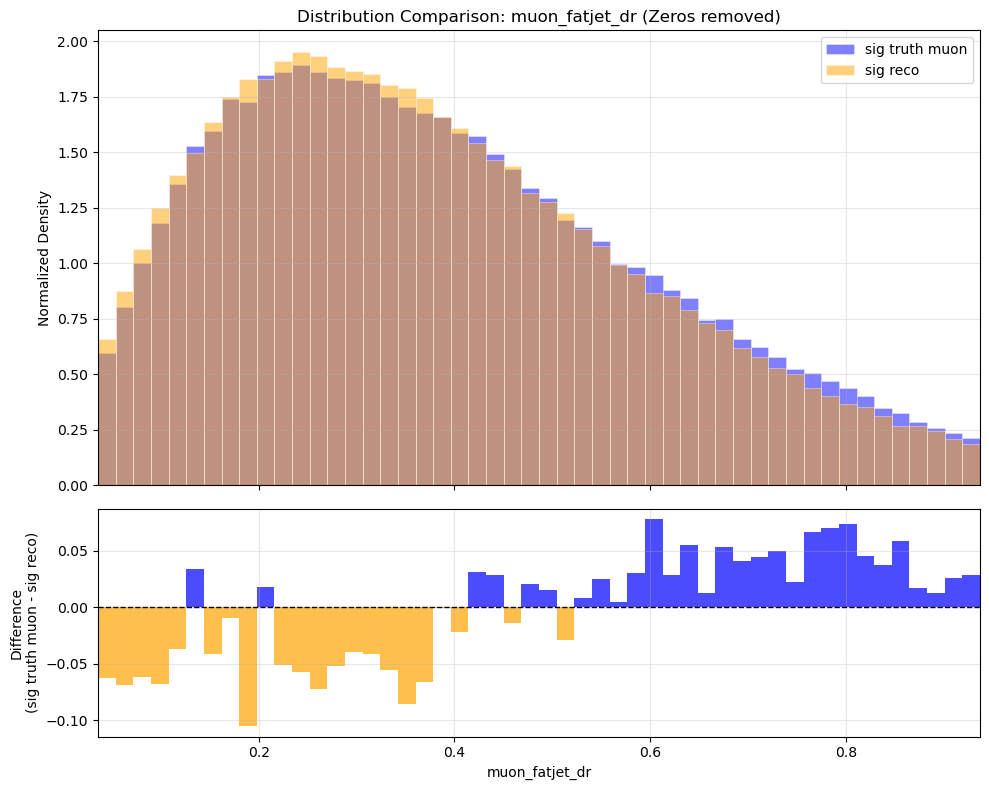

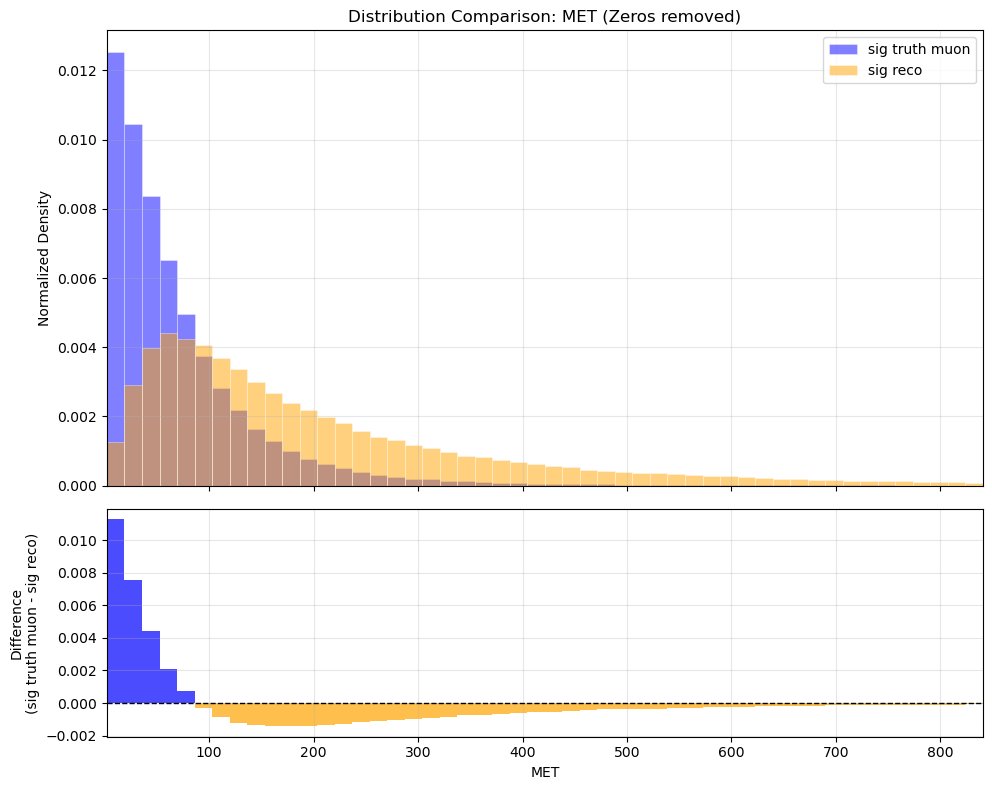

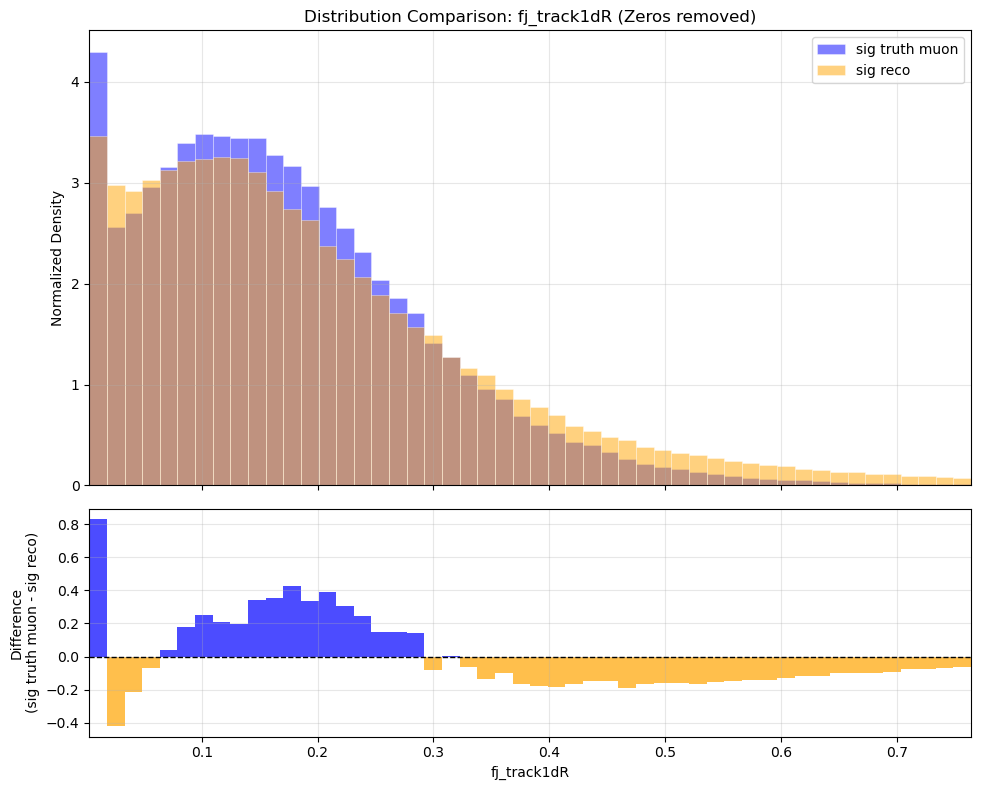

In [33]:
plot_histogram_diffs(df_sig_truth_mu[df_sig_truth_mu['muonPt']>20], df_sig_reco[df_sig_reco['fatJetPt']>200], 
                     ["MET", "fj_track1dR"], df1_label = "sig truth muon", df2_label = "sig reco")

In [ ]:
plot_histogram_by_type(df_bkg_truth, "

In [ ]:
track_eta = f"fj_track1Eta"
track_phi = f"fj_track1Phi"
df_bkg_reco["fj_track1_muon_dr"] = delta_r(df_bkg_reco["muonEta"], df_bkg_reco[track_eta], df_bkg_reco["muonPhi"], df_bkg_reco[track_phi])
df_bkg_reco["fj_track1_jet2_dr"] = delta_r(df_bkg_reco["jet2Eta"], df_bkg_reco[track_eta], df_bkg_reco["jet2Phi"], df_bkg_reco[track_phi])
df_bkg_reco["fj_track1_jet1_dr"] = delta_r(df_bkg_reco["jet1Eta"], df_bkg_reco[track_eta], df_bkg_reco["jet1Phi"], df_bkg_reco[track_phi])

track_eta = f"fj_track2Eta"
track_phi = f"fj_track2Phi"
df_bkg_reco["fj_track2_jet2_dr"] = delta_r(df_bkg_reco["jet2Eta"], df_bkg_reco[track_eta], df_bkg_reco["jet2Phi"], df_bkg_reco[track_phi])
df_bkg_reco["fj_track2_jet1_dr"] = delta_r(df_bkg_reco["jet1Eta"], df_bkg_reco[track_eta], df_bkg_reco["jet1Phi"], df_bkg_reco[track_phi])

df_bkg_reco["fatJet_jet2_dr"] = delta_r(df_bkg_reco["jet2Eta"], df_bkg_reco["fatJetEta"], df_bkg_reco["jet2Phi"], df_bkg_reco["fatJetPhi"])
df_bkg_reco["fatJet_jet1_dr"] = delta_r(df_bkg_reco["jet1Eta"], df_bkg_reco["fatJetEta"], df_bkg_reco["jet1Phi"], df_bkg_reco["fatJetPhi"])

df_bkg_reco["muon_jet2_dr"] = delta_r(df_bkg_reco["jet2Eta"], df_bkg_reco["muonEta"], df_bkg_reco["jet2Phi"], df_bkg_reco["muonPhi"])
df_bkg_reco["muon_jet1_dr"] = delta_r(df_bkg_reco["jet1Eta"], df_bkg_reco["muonEta"], df_bkg_reco["jet1Phi"], df_bkg_reco["muonPhi"])

track_eta = f"fj_track1Eta"
track_phi = f"fj_track1Phi"
df_sig_reco["fj_track1_muon_dr"] = delta_r(df_sig_reco["muonEta"], df_sig_reco[track_eta], df_sig_reco["muonPhi"], df_sig_reco[track_phi])
df_sig_reco["fj_track1_jet2_dr"] = delta_r(df_sig_reco["jet2Eta"], df_sig_reco[track_eta], df_sig_reco["jet2Phi"], df_sig_reco[track_phi])
df_sig_reco["fj_track1_jet1_dr"] = delta_r(df_sig_reco["jet1Eta"], df_sig_reco[track_eta], df_sig_reco["jet1Phi"], df_sig_reco[track_phi])
track_eta = f"fj_track2Eta"
track_phi = f"fj_track2Phi"
df_sig_reco["fj_track2_jet2_dr"] = delta_r(df_sig_reco["jet2Eta"], df_sig_reco[track_eta], df_sig_reco["jet2Phi"], df_sig_reco[track_phi])
df_sig_reco["fj_track2_jet1_dr"] = delta_r(df_sig_reco["jet1Eta"], df_sig_reco[track_eta], df_sig_reco["jet1Phi"], df_sig_reco[track_phi])
df_sig_reco["fatJet_jet2_dr"] = delta_r(df_sig_reco["jet2Eta"], df_sig_reco["fatJetEta"], df_sig_reco["jet2Phi"], df_sig_reco["fatJetPhi"])
df_sig_reco["fatJet_jet1_dr"] = delta_r(df_sig_reco["jet1Eta"], df_sig_reco["fatJetEta"], df_sig_reco["jet1Phi"], df_sig_reco["fatJetPhi"])

df_sig_reco["muon_jet2_dr"] = delta_r(df_sig_reco["jet2Eta"], df_sig_reco["muonEta"], df_sig_reco["jet2Phi"], df_sig_reco["muonPhi"])
df_sig_reco["muon_jet1_dr"] = delta_r(df_sig_reco["jet1Eta"], df_sig_reco["muonEta"], df_sig_reco["jet1Phi"], df_sig_reco["muonPhi"])

In [ ]:
plot_histogram(df_bkg_reco[df_bkg_reco['fatJet_jet1_dr']<0.1], "fatJet_jet1_dr")

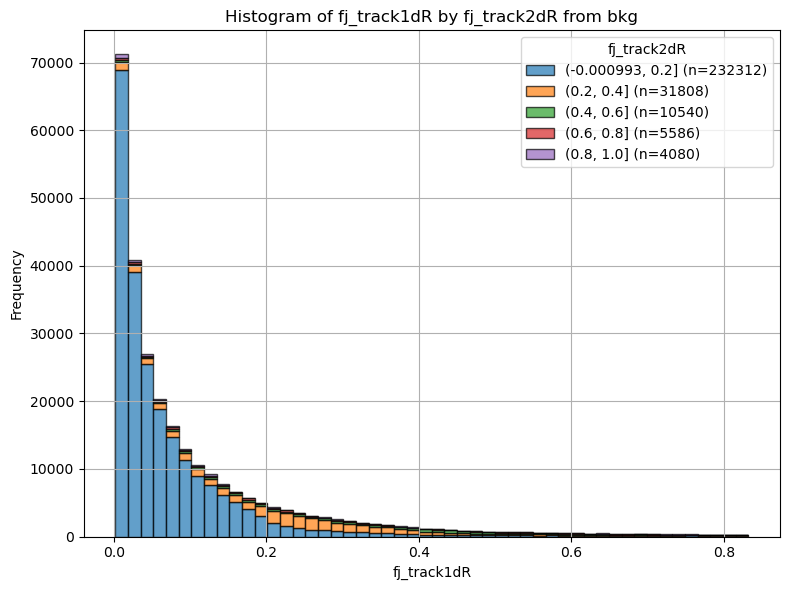

In [64]:
plot_histogram_by_type(df_bkg_reco, "fj_track1dR", "fj_track2dR", filename="bkg")

In [232]:
print(df_bkg_reco.keys()[:40])

Index(['numOfInDetTracks', 'numOfFatJets', 'fatJetPt', 'fatJetEta',
       'fatJetPhi', 'fatJetM', 'fatJetD2', 'jet1Pt', 'jet1Eta', 'jet1Phi',
       'jet1M', 'jet2Pt', 'jet2Eta', 'jet2Phi', 'jet2M', 'MET', 'METPhi',
       'numOfMuons', 'muonPt', 'muonEta', 'muonPhi', 'muonM', 'muonCharge',
       'muonTruthOrigin', 'muon_fatjet_deta', 'muon_fatjet_dphi',
       'muon_fatjet_dr', 'numOfInDetTracks_inFJCone', 'fj_track1Pt',
       'fj_track1Eta', 'fj_track1Phi', 'fj_track1TruthOrigin',
       'fj_track1TruthType', 'fj_track2Pt', 'fj_track2Eta', 'fj_track2Phi',
       'fj_track2TruthOrigin', 'fj_track2TruthType', 'fj_track3Pt',
       'fj_track3Eta'],
      dtype='object')


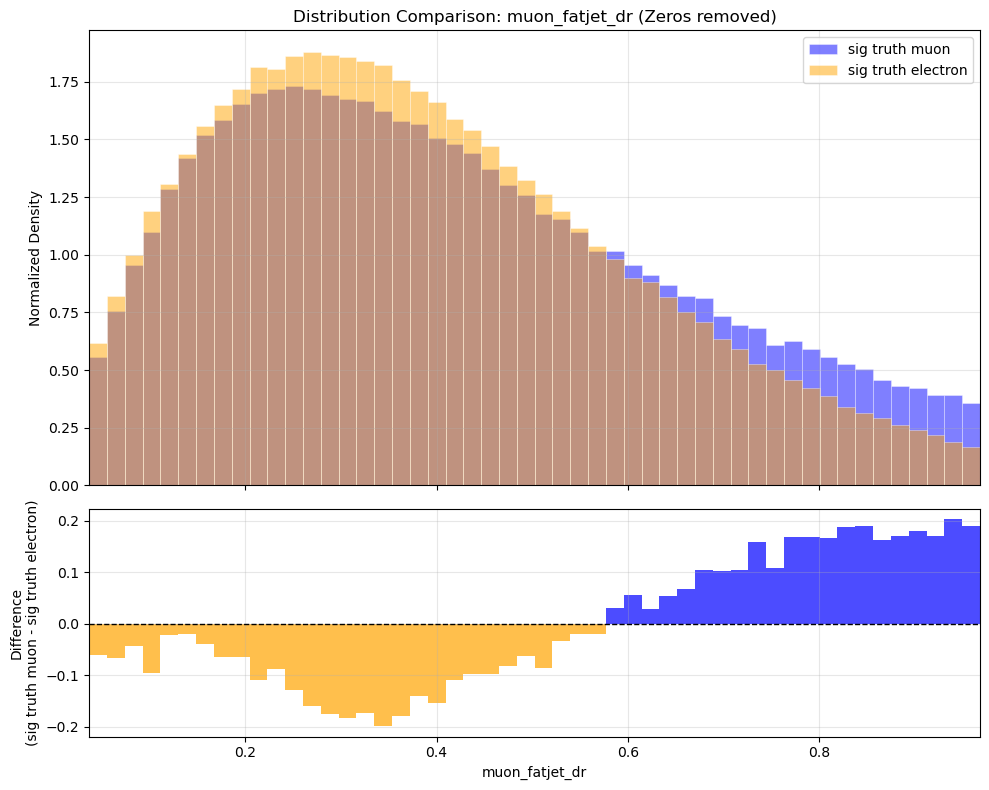

In [79]:
plot_histogram_diffs(df_sig_truth[df_sig_truth['lepId']==-13], df_sig_reco, 
                     ['muon_fatjet_dr'], df1_label ="sig truth muon", df2_label = "sig truth electron")

In [93]:
df_bkg_truth[df_bkg_truth['lepId'].abs() == 13]

,MET,METPhi,fatJetPt,fatJetEta,fatJetPhi,fatJetM,fatJetD2,numOfInDetTracks_inFJCone,numOfFatJets,jet1Pt,...,fj_track28dEta,fj_track28dPhi,fj_track28dR,fj_track29dEta,fj_track29dPhi,fj_track29dR,fj_track30dEta,fj_track30dPhi,fj_track30dR,event_index
0,165.518391,-0.750628,211.958250,2.227066,2.107259,51.345730,0.205136,25,1,66.895266,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5
3,72.987250,0.210554,204.828000,0.592110,-1.483112,31.302852,0.295823,25,1,236.246797,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,189
4,35.245238,1.480121,221.848437,0.807714,-1.662898,19.903818,0.329167,26,1,260.781641,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,206
5,54.738684,0.824542,250.611063,-1.037473,-2.537782,132.317000,0.216020,46,1,185.162297,...,-0.157032,0.670872,0.689005,-0.203495,0.605211,0.638507,-0.203853,0.024405,0.205308,303
6,286.233219,-2.200894,279.851875,-0.510496,0.837405,10.825982,0.257302,12,1,32.783695,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,328
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
194535,231.543688,2.806797,360.628719,1.836239,2.916086,19.475635,0.089704,12,1,736.914500,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,499991
194536,122.504852,-1.423784,583.486500,-1.738206,-0.230999,79.769430,0.236393,35,1,719.103313,...,-0.313112,-0.053989,0.317733,-0.038851,-0.193121,0.196990,0.108488,0.165141,0.197588,499992
194537,9.724608,-2.223656,449.040344,-0.426603,-2.420012,19.377100,0.285835,26,1,597.271562,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,499994
194538,51.423195,1.211160,349.258125,-0.045564,-2.050752,107.976305,0.218669,47,1,275.562687,...,0.128830,-0.387891,0.408725,0.356330,0.068643,0.362881,-0.183760,-0.101164,0.209766,499995


In [249]:
import pandas as pd
import numpy as np

def filter_and_scale_tracks(df, max_tracks=30):
    """
    Removes tracks with TruthType == 6, sorts remaining by Pt, 
    pads with zeros, and computes relPt.
    """
    # 1. Create a unique event ID to keep track of rows during the melt/pivot
    df = df.copy()
    df['event_id'] = df.index
    
    # This correctly isolates ['Pt', 'Eta', 'Phi', 'TruthOrigin', 'TruthType']
    # and prevents tracks 10-19 from bleeding into the variable list.
    track_vars = ['Pt', 'Eta', 'Phi', 'TruthOrigin', 'TruthType', 'dEta', 'dPhi', 'dR']
    print(track_vars,"\n")
    # 3. "Melt" the data into a long format (one row per track)
    track_data = []
    for i in range(1, max_tracks + 1):
        cols = [f'fj_track{i}{var}' for var in track_vars]
        # Only process if columns exist to avoid KeyErrors
        if set(cols).issubset(df.columns):
            temp = df[['event_id'] + cols].copy()
            temp.columns = ['event_id'] + track_vars  # Standardize names
            track_data.append(temp)
            
    long_df = pd.concat(track_data, ignore_index=True)
    print(long_df.head(),"\n")    
    # 4. Filter out the unwanted tracks
    long_df = long_df[long_df['TruthType'] != 6]
    
    # 5. Sort remaining tracks by event_id (ascending) and Pt (descending)
    long_df = long_df.sort_values(by=['event_id', 'Pt'], ascending=[True, False])
    
    # 6. Assign new track ranks (1, 2, 3...) to the remaining sorted tracks
    long_df['new_track_id'] = long_df.groupby('event_id').cumcount() + 1
    print(long_df.head(),"\n")
    
    # 7. Pivot back to the wide format
    wide_df = long_df.pivot(index='event_id', columns='new_track_id', values=track_vars)
    print(wide_df.head(),"\n")
    
    # Flatten the MultiIndex columns and reconstruct the original names (e.g., fj_track1Pt)
    wide_df.columns = [f'fj_track{col[1]}{col[0]}' for col in wide_df.columns]
    print(wide_df.head(),"\n")
    # 8. Reindex to ensure we have exactly columns 1 through 30
    expected_cols = []
    for i in range(1, max_tracks + 1):
        for var in track_vars:
            expected_cols.append(f'fj_track{i}{var}')
            
    wide_df = wide_df.reindex(columns=expected_cols)
    
    # 9. Merge back with non-track columns (like fatJetPt)
    # Using a left join ensures that if an event had ALL its tracks removed, it still survives
    non_track_cols = [c for c in df.columns if not c.startswith('fj_track') and c != 'event_id']
    final_df = df[['event_id'] + non_track_cols].set_index('event_id')
    print(final_df.head(),"\n")
    # Join and replace any missing/shifted tracks with 0
    final_df = final_df.join(wide_df, how='left').fillna(0)
    
    # 10. Compute the relPt for all 30 tracks
    for i in range(1, max_tracks + 1):
        pt_col = f'fj_track{i}Pt'
        rel_col = f'fj_track{i}relPt'
        
        # Using np.where protects against dividing by a fatJetPt of 0
        final_df[rel_col] = np.where(
            final_df['fatJetPt'] != 0, 
            final_df[pt_col] / final_df['fatJetPt'], 
            0
        )
        
    return final_df.reset_index(drop=True)

# Example usage:
# df_sig_cleaned = filter_and_scale_tracks(df_sig_reco)
# df_bkg_cleaned = filter_and_scale_tracks(df_bkg_reco)

In [ ]:
df_sig_reco_cleaned = filter_and_scale_tracks(df_sig_reco)
df_bkg_reco_cleaned = filter_and_scale_tracks(df_bkg_reco)

In [251]:
pd.set_option('display.max_columns', None)

# 2. Inspect the first 5 rows (5 is the default for head)
df_sig_reco_cleaned.head()

,numOfInDetTracks,numOfFatJets,fatJetPt,fatJetEta,fatJetPhi,fatJetM,fatJetD2,jet1Pt,jet1Eta,jet1Phi,jet1M,jet2Pt,jet2Eta,jet2Phi,jet2M,MET,METPhi,numOfMuons,muonPt,muonEta,muonPhi,muonM,muonCharge,muonTruthOrigin,muon_fatjet_deta,muon_fatjet_dphi,muon_fatjet_dr,numOfInDetTracks_inFJCone,fatJet_jet2_dr,fatJet_jet1_dr,muon_jet2_dr,muon_jet1_dr,fj_track1Pt,fj_track1Eta,fj_track1Phi,fj_track1TruthOrigin,fj_track1TruthType,fj_track1dEta,fj_track1dPhi,fj_track1dR,fj_track2Pt,fj_track2Eta,fj_track2Phi,fj_track2TruthOrigin,fj_track2TruthType,fj_track2dEta,fj_track2dPhi,fj_track2dR,fj_track3Pt,fj_track3Eta,fj_track3Phi,fj_track3TruthOrigin,fj_track3TruthType,fj_track3dEta,fj_track3dPhi,fj_track3dR,fj_track4Pt,fj_track4Eta,fj_track4Phi,fj_track4TruthOrigin,fj_track4TruthType,fj_track4dEta,fj_track4dPhi,fj_track4dR,fj_track5Pt,fj_track5Eta,fj_track5Phi,fj_track5TruthOrigin,fj_track5TruthType,fj_track5dEta,fj_track5dPhi,fj_track5dR,fj_track6Pt,fj_track6Eta,fj_track6Phi,fj_track6TruthOrigin,fj_track6TruthType,fj_track6dEta,fj_track6dPhi,fj_track6dR,fj_track7Pt,fj_track7Eta,fj_track7Phi,fj_track7TruthOrigin,fj_track7TruthType,fj_track7dEta,fj_track7dPhi,fj_track7dR,fj_track8Pt,fj_track8Eta,fj_track8Phi,fj_track8TruthOrigin,fj_track8TruthType,fj_track8dEta,fj_track8dPhi,fj_track8dR,fj_track9Pt,fj_track9Eta,fj_track9Phi,fj_track9TruthOrigin,fj_track9TruthType,fj_track9dEta,fj_track9dPhi,fj_track9dR,fj_track10Pt,fj_track10Eta,fj_track10Phi,fj_track10TruthOrigin,fj_track10TruthType,fj_track10dEta,fj_track10dPhi,fj_track10dR,fj_track11Pt,fj_track11Eta,fj_track11Phi,fj_track11TruthOrigin,fj_track11TruthType,fj_track11dEta,fj_track11dPhi,fj_track11dR,fj_track12Pt,fj_track12Eta,fj_track12Phi,fj_track12TruthOrigin,fj_track12TruthType,fj_track12dEta,fj_track12dPhi,fj_track12dR,fj_track13Pt,fj_track13Eta,fj_track13Phi,fj_track13TruthOrigin,fj_track13TruthType,fj_track13dEta,fj_track13dPhi,fj_track13dR,fj_track14Pt,fj_track14Eta,fj_track14Phi,fj_track14TruthOrigin,fj_track14TruthType,fj_track14dEta,fj_track14dPhi,fj_track14dR,fj_track15Pt,fj_track15Eta,fj_track15Phi,fj_track15TruthOrigin,fj_track15TruthType,fj_track15dEta,fj_track15dPhi,fj_track15dR,fj_track16Pt,fj_track16Eta,fj_track16Phi,fj_track16TruthOrigin,fj_track16TruthType,fj_track16dEta,fj_track16dPhi,fj_track16dR,fj_track17Pt,fj_track17Eta,fj_track17Phi,fj_track17TruthOrigin,fj_track17TruthType,fj_track17dEta,fj_track17dPhi,fj_track17dR,fj_track18Pt,fj_track18Eta,fj_track18Phi,fj_track18TruthOrigin,fj_track18TruthType,fj_track18dEta,fj_track18dPhi,fj_track18dR,fj_track19Pt,fj_track19Eta,fj_track19Phi,fj_track19TruthOrigin,fj_track19TruthType,fj_track19dEta,fj_track19dPhi,fj_track19dR,fj_track20Pt,fj_track20Eta,fj_track20Phi,fj_track20TruthOrigin,fj_track20TruthType,fj_track20dEta,fj_track20dPhi,fj_track20dR,fj_track21Pt,fj_track21Eta,fj_track21Phi,fj_track21TruthOrigin,fj_track21TruthType,fj_track21dEta,fj_track21dPhi,fj_track21dR,fj_track22Pt,fj_track22Eta,fj_track22Phi,fj_track22TruthOrigin,fj_track22TruthType,fj_track22dEta,fj_track22dPhi,fj_track22dR,fj_track23Pt,fj_track23Eta,fj_track23Phi,fj_track23TruthOrigin,fj_track23TruthType,fj_track23dEta,fj_track23dPhi,fj_track23dR,fj_track24Pt,fj_track24Eta,fj_track24Phi,fj_track24TruthOrigin,fj_track24TruthType,fj_track24dEta,fj_track24dPhi,fj_track24dR,fj_track25Pt,fj_track25Eta,fj_track25Phi,fj_track25TruthOrigin,fj_track25TruthType,fj_track25dEta,fj_track25dPhi,fj_track25dR,fj_track26Pt,fj_track26Eta,fj_track26Phi,fj_track26TruthOrigin,fj_track26TruthType,fj_track26dEta,fj_track26dPhi,fj_track26dR,fj_track27Pt,fj_track27Eta,fj_track27Phi,fj_track27TruthOrigin,fj_track27TruthType,fj_track27dEta,fj_track27dPhi,fj_track27dR,fj_track28Pt,fj_track28Eta,fj_track28Phi,fj_track28TruthOrigin,fj_track28TruthType,fj_track28dEta,fj_track28dPhi,fj_track28dR,fj_track29Pt,fj_track29Eta,fj_track29Phi,fj_track29TruthOrigin,fj_track29TruthType,fj_track29dEta,fj_track29dPhi,fj_track29dR,fj_track30Pt,fj_track30Eta,fj_track30Phi,fj_track30TruthOrigin,fj_track30T

In [12]:
df_sig_reco.to_parquet("data_reco/df_sig_cleaned_noMu.parquet")

In [13]:
df_bkg_reco.to_parquet("data_reco/df_bkg_cleaned_noMU.parquet")

In [70]:
plot_histogram_by_type(df_bkg_reco_cleaned, "fj_track1dR", "", filename="bkg")

NameError: name 'df_bkg_reco_cleaned' is not defined

In [101]:
df_sig_j = pl.read_parquet("data_filtered/signal_df_j.parquet").to_pandas()
df_sig_fj = pl.read_parquet("data_filtered/signal_df_fj.parquet").to_pandas()
df_sig_fjc = pl.read_parquet("data_filtered/signal_df_fjc.parquet").to_pandas()
df_sig_lep = pl.read_parquet("data_filtered/signal_df_lep.parquet").to_pandas()
df_sig_met = pl.read_parquet("data_filtered/signal_df_met.parquet").to_pandas()
df_sig_higgs = pl.read_parquet("data_filtered/signal_df_higgs.parquet").to_pandas()

In [41]:
print("df_j:")
df_sig_j.info()
print("df_fj:")
df_sig_fj.info()
print("df_fjc:")
df_sig_fjc.info()
print("df_lep:") 
df_sig_lep.info()
print("df_met:")
df_sig_met.info()
print("df_higgs:")
df_sig_higgs.info()

df_j:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1868602 entries, 0 to 1868601
Data columns (total 7 columns):
 #   Column             Dtype  
---  ------             -----  
 0   eta                float64
 1   phi                float64
 2   pt                 float64
 3   m                  float64
 4   event_index        int64  
 5   index              int64  
 6   __index_level_0__  int64  
dtypes: float64(4), int64(3)
memory usage: 99.8 MB
df_fj:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 895796 entries, 0 to 895795
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   eta                895796 non-null  float64
 1   phi                895796 non-null  float64
 2   pt                 895796 non-null  float64
 3   m                  895796 non-null  float64
 4   D2                 894324 non-null  float64
 5   event_index        895796 non-null  int64  
 6   index              895796 non

In [115]:
import pandas as pd
import numpy as np

def delta_phi(phi1, phi2):
    """Vectorized calculation of delta phi, wrapped to [-pi, pi]."""
    dphi = phi1 - phi2
    return (dphi + np.pi) % (2 * np.pi) - np.pi

def delta_r(eta1, phi1, eta2, phi2):
    """Vectorized calculation of delta R."""
    deta = eta1 - eta2
    dphi = delta_phi(phi1, phi2)
    return np.sqrt(deta**2 + dphi**2)

def build_event_dataframe(df_j, df_fj, df_fjc, df_lep, df_met, df_higgs=None):
    """
    Merges and reshapes multiple object-level DataFrames into a single flat 
    event-level DataFrame.
    """
    
    # 1. MET (One per event)
    met = df_met[['event_index', 'pt', 'phi']].copy()
    met.rename(columns={'pt': 'MET', 'phi': 'METPhi'}, inplace=True)
    met.set_index('event_index', inplace=True)

    # 2. Fat Jets (Keep leading, count total)
    fj = df_fj.sort_values(['event_index', 'pt'], ascending=[True, False])
    fj_leading = fj.drop_duplicates('event_index', keep='first').copy()
    fj_leading.rename(columns={
        'pt': 'fatJetPt', 'eta': 'fatJetEta', 'phi': 'fatJetPhi',
        'm': 'fatJetM', 'D2': 'fatJetD2', 'count': 'numOfInDetTracks_inFJCone'
    }, inplace=True)
    fj_leading.set_index('event_index', inplace=True)
    fj_out = fj_leading[['fatJetPt', 'fatJetEta', 'fatJetPhi', 'fatJetM', 'fatJetD2', 'numOfInDetTracks_inFJCone']]

    # 3. Jets (Extract top 2)
    j = df_j.sort_values(['event_index', 'pt'], ascending=[True, False])
    j['jet_rank'] = j.groupby('event_index').cumcount() + 1
    j_top2 = j[j['jet_rank'] <= 2].copy()
    
    # Pivot rows into columns
    j_pivoted = j_top2.set_index(['event_index', 'jet_rank'])[['pt', 'eta', 'phi', 'm']].unstack()
    j_pivoted.columns = [[f'jet{rank}{col.capitalize()}' for col, rank in j_pivoted.columns]
                        ]
    # 4. Leptons / Muons (Keep leading, count total)
    lep = df_lep.sort_values(['event_index', 'pt'], ascending=[True, False])
    lep_leading = lep.drop_duplicates('event_index', keep='first').copy()
    
    # Assuming PDG ID (13 = mu-, -13 = mu+). Charge is -sign(id)
    lep_leading.rename(columns={'pt': 'muonPt', 'eta': 'muonEta', 'phi': 'muonPhi', 'id': 'lepId'}, inplace=True)
    lep_leading.set_index('event_index', inplace=True)
    lep_out = lep_leading[['muonPt', 'muonEta', 'muonPhi', 'lepId']]

    # 5. Fat Jet Constituents (Extract top 30)
    fjc = df_fjc.sort_values(['event_index', 'pt'], ascending=[True, False])
    fjc_top30 = fjc.groupby('event_index').head(30).copy()
    fjc_top30['track_rank'] = fjc_top30.groupby('event_index').cumcount() + 1
    
    # Pivot rows into columns
    fjc_pivoted = fjc_top30.set_index(['event_index', 'track_rank'])[['pt', 'eta', 'phi', 'm']].unstack()
    fjc_pivoted.columns = [f'fj_track{rank}{col.capitalize()}' for col, rank in fjc_pivoted.columns]
    fjc_out = fjc_pivoted

    # 6. Merge all datasets together
    dfs_to_merge = [met, fj_out, j_pivoted, lep_out, fjc_out]
    if df_higgs is not None:
        higgs = df_higgs.set_index('event_index')[['Higgs_pt', 'Higgs_eta', 'Higgs_phi']]
        dfs_to_merge.append(higgs)

    df_final = pd.concat(dfs_to_merge, axis=1)

    # 7. Compute Derived Kinematics (dR, dEta, dPhi)
    # Muon to Fat Jet
    if 'muonEta' in df_final.columns and 'fatJetEta' in df_final.columns:
        df_final['muon_fatjet_deta'] = df_final['muonEta'] - df_final['fatJetEta']
        df_final['muon_fatjet_dphi'] = delta_phi(df_final['muonPhi'], df_final['fatJetPhi'])
        df_final['muon_fatjet_dr'] = np.sqrt(df_final['muon_fatjet_deta']**2 + df_final['muon_fatjet_dphi']**2)

    # Jets to Fat Jet
    if 'jet1Eta' in df_final.columns and 'fatJetEta' in df_final.columns:
        df_final['fatJet_jet1_dr'] = delta_r(df_final['fatJetEta'], df_final['fatJetPhi'], 
                                             df_final['jet1Eta'], df_final['jet1Phi'])
    if 'jet2Eta' in df_final.columns and 'fatJetEta' in df_final.columns:
        df_final['fatJet_jet2_dr'] = delta_r(df_final['fatJetEta'], df_final['fatJetPhi'], 
                                             df_final['jet2Eta'], df_final['jet2Phi'])

    # Tracks to Fat Jet
    # Loop over up to 30 tracks dynamically based on what exists in the data
    max_tracks = df_final.filter(like='fj_track').filter(like='Eta').shape[1]
    for i in range(1, max_tracks + 1):
        eta_col = f'fj_track{i}Eta'
        phi_col = f'fj_track{i}Phi'
        if eta_col in df_final.columns:
            df_final[f'fj_track{i}dEta'] = df_final[eta_col] - df_final['fatJetEta']
            df_final[f'fj_track{i}dPhi'] = delta_phi(df_final[phi_col], df_final['fatJetPhi'])
            df_final[f'fj_track{i}dR'] = np.sqrt(df_final[f'fj_track{i}dEta']**2 + df_final[f'fj_track{i}dPhi']**2)

    return df_final

In [116]:
print(df_sig_fj.head(5))

        eta       phi         pt           m        D2  event_index  index  \
0 -1.305899 -1.758322  341919.72   93334.970  0.179063            7      1   
1 -1.914104  2.719653  254758.03  113848.510  0.220359           13      0   
2 -0.462934  1.712915  266244.75   92070.350  0.170285           17      1   
3  2.067106  0.045983  277440.12   86642.766  0.094879           19      0   
4 -0.721390  1.515283  255669.81   63837.137  0.144465           20      1   

   count  __index_level_0__  
0     30                  4  
1     40                  7  
2     19                 10  
3     22                 12  
4     23                 13  


In [117]:
df_sig_truth_flat = build_event_dataframe(df_sig_j, df_sig_fj, df_sig_fjc, df_sig_lep, df_sig_met, df_sig_higgs)

/tmp/ipykernel_2459/438981857.py:96: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_final[f'fj_track{i}dR'] = np.sqrt(df_final[f'fj_track{i}dEta']**2 + df_final[f'fj_track{i}dPhi']**2)


In [63]:
df_bkg_j = pl.read_parquet("data_filtered/background_1000_df_j.parquet").to_pandas()
df_bkg_fj = pl.read_parquet("data_filtered/background_1000_df_fj.parquet").to_pandas()
df_bkg_fjc = pl.read_parquet("data_filtered/background_1000_df_fjc.parquet").to_pandas()
df_bkg_lep = pl.read_parquet("data_filtered/background_1000_df_lep.parquet").to_pandas()
df_bkg_met = pl.read_parquet("data_filtered/background_1000_df_met.parquet").to_pandas()


In [64]:
df_bkg_truth_flat = build_event_dataframe(df_bkg_j, df_bkg_fj, df_bkg_fjc, df_bkg_lep, df_bkg_met)

/tmp/ipykernel_157/3858613070.py:99: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_final[f'fj_track{i}dPhi'] = delta_phi(df_final[phi_col], df_final['fatJetPhi'])
/tmp/ipykernel_157/3858613070.py:100: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_final[f'fj_track{i}dR'] = np.sqrt(df_final[f'fj_track{i}dEta']**2 + df_final[f'fj_track{i}dPhi']**2)


In [65]:
df_bkg_truth_flat.to_parquet("df_bg1000_truth_flat.parquet")

In [94]:
df_sig_truth.to_parquet("df_sig_truth_flat.parquet")

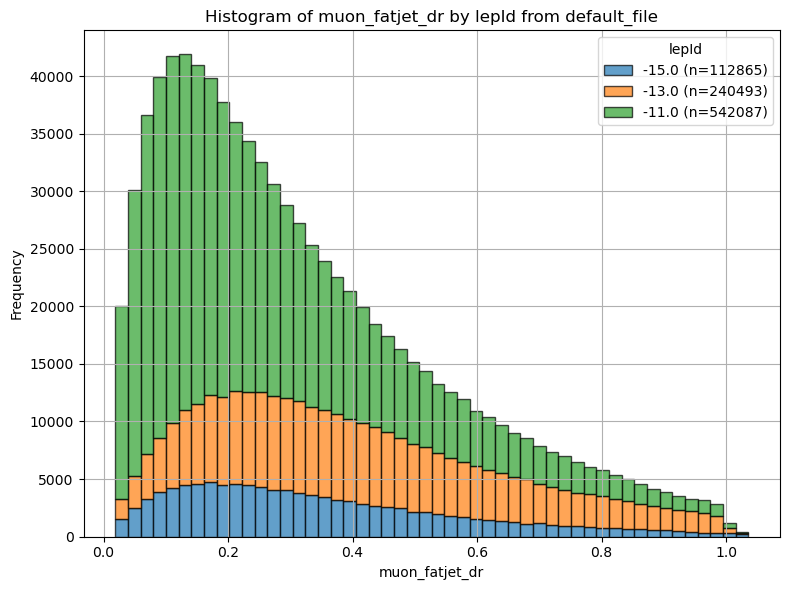

In [119]:
plot_histogram_by_type(df_sig_truth_flat, "muon_fatjet_dr", 'lepId')